# Dynamic Analytical Dashboard with Python — ShopEase E-Commerce Orders
### Foundations of Big Data Analytics with Python (FBDA) · Group Project

## 1. Project Information

| Field | Details |
|---|---|
| **Project Title** | Dynamic Analytical Dashboard with Python: Sales, Satisfaction & Cancellation Analytics for ShopEase |
| **Group Number / Group ID** | **011_023_048** |
| **Random Seed** (`random.seed` & `random_state`) | **112348** |
| **Student 1** | *[Name]* — Enrollment No. *[…011]* |
| **Student 2** | *[Name]* — Enrollment No. *[…023]* |
| **Student 3** | *[Name]* — Enrollment No. *[…048]* |
| **Live Data Link** | *[paste raw GitHub link of `shopease_raw_orders.csv`]* |
| **Live Dashboard Link** | *[paste Streamlit Community Cloud link, e.g. https://shopease-011-023-048.streamlit.app]* |

**Contents:** 1 Project Information · 2 Description of Data · 3 Objectives · 4 Analysis of Data (cleaning, sampling, descriptive, visualization, inferential, regression) · 5 Observations & Findings · 6 Managerial Insights & Recommendations · 7 Streamlit Dashboard · Appendix 1 Individual Contribution · Appendix 2 AI Prompt Logs

> **How to run:** Runtime → Run all. The notebook reads the CSV from the live data link (or asks you to upload it), cleans it, draws the 2,500-record sample with seed 112348 and reproduces every result below.

In [1]:
# ============ 0. SETUP ============
import os, io, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", palette="deep")

GROUP_ID = "011_023_048"
# Brief: "001_010_100" -> 110100, i.e. leading zeros of each part dropped, then joined
SEED = int("".join(str(int(p)) for p in GROUP_ID.split("_")))
random.seed(SEED); np.random.seed(SEED)
ALPHA = 0.05
print("Group ID:", GROUP_ID, "| Seed (random.seed & random_state):", SEED)

Group ID: 011_023_048 | Seed (random.seed & random_state): 112348


In [2]:
# ============ LOAD RAW DATA ============
# Replace with the raw GitHub link of the CSV (live data link for the submission)
DATA_URL = "https://raw.githubusercontent.com/<your-username>/<your-repo>/main/shopease_raw_orders.csv"
LOCAL_FILE = "shopease_raw_orders.csv"

if os.path.exists(LOCAL_FILE):
    df_raw = pd.read_csv(LOCAL_FILE)
else:
    try:
        df_raw = pd.read_csv(DATA_URL)
    except Exception:
        from google.colab import files          # fallback: upload manually in Colab
        up = files.upload()
        df_raw = pd.read_csv(io.BytesIO(up[list(up.keys())[0]]))

print("Raw shape:", df_raw.shape)
df_raw.head(10)

Raw shape: (10020, 16)


,OrderID,CustomerID,OrderDate,CustomerAge,Gender,City,Category,Product,Quantity,UnitPrice,Discount,PaymentMethod,OrderStatus,DeliveryDate,Rating,TotalAmount
0,18129,C0507,2026-02-01 23:39:00,68.0000,Female,Alexandria,Electronics,Laptop,4,18000,0.0,Wallet,Delivered,2026-02-04 23:39:00,5.0000,"72,000.0000"
1,11666,C0207,2026-03-03 10:37:00,21.0000,Female,Cairo,Sports,Yoga Mat,2,600,0.1,Wallet,Delivered,2026-03-07 10:37:00,1.0000,"1,080.0000"
2,12859,C1112,2026-05-23 17:57:00,23.0000,Male,Aswan,Fashion,Shoes,-1,1500,10%,Bank Transfer,Delivered,2026-05-27 17:57:00,4.0000,"1,350.0000"
3,19787,C1322,2026-01-29 07:51:00,23.0000,Male,Tanta,Beauty,Hair Dryer,4,1300,0.1,Wallet,Delivered,2026-01-30 07:51:00,4.0000,"4,680.0000"
4,16473,C0314,2026-06-23 20:17:00,62.0000,Female,Tanta,Electronics,Laptop,1,18000,0.1,Mastercard,Delivered,2026-06-27 20:17:00,5.0000,"16,200.0000"
5,18080,C0405,2026-05-03 07:49:00,53.0000,Female,Giza,Fashion,Jacket,4,1200,0.1,Wallet,Delivered,2026-05-05 07:49:00,5.0000,"4,320.0000"
6,16083,C1290,2026-03-14 01:55:00,38.0000,Female,Tanta,Sports,Tennis Racket,2,1600,0.1,Visa,Delivered,2026-03-16 01:55:00,3.0000,"2,880.0000"
7,17384,C1810,2026-06-26 17:19:00,56.0000,Male,Giza,Beauty,Makeup Kit,4,900,0.1,Visa,Delivered,2026-06-29 17:19:00,4.0000,"3,240.0000"
8,18401,C0683,24-02-2026,40.0000,Female,Cairo,Sports,Running Shoes,4,1800,0.0,Wallet,Delivered,2026-02-26 07:50:00,3.0000,"7,200.0000"
9,13145,C0967,2026-03-18 16:44:00,49.0000,Female,Mansoura,Home,Lamp,3,300,0.2,Cash,Pending,NaN,NaN,720.0000


## 2. Description of Data

| Item | Details |
|---|---|
| **Data Name** | ShopEase Raw Orders (`shopease_raw_orders.csv`) |
| **Data Source (weblink)** | Course project dataset — *<paste the dataset link from the project brief / raw GitHub link here>* |
| **Data Size** | ≈ 1.19 MB (1,191,930 bytes) |
| **Data Type** | **Cross-sectional** (one record per order) with a time-stamp (`OrderDate`) that allows time-series aggregation |
| **Dataset Span** | **Static** snapshot — orders from **Jan 2026 to Jun 2026** (6 months); not updated |
| **Data Dimension (raw)** | **16 variables × 10,020 records** |
| **Data Dimension (clean)** | 16 original + 6 derived variables × 10,000 records |
| **Analysis Sample** | **2,500 random records** drawn with `random_state = 112348` |

In [3]:
# ---- Size, dimensions and data types ----
size_kb = os.path.getsize(LOCAL_FILE)/1024 if os.path.exists(LOCAL_FILE) else len(df_raw.to_csv(index=False).encode())/1024
print(f"Data size: {size_kb:,.1f} KB  (~{size_kb/1024:.2f} MB)")
print("Dimension:", df_raw.shape[1], "variables x", df_raw.shape[0], "observations\n")
df_raw.info()

Data size: 1,164.0 KB  (~1.14 MB)
Dimension: 16 variables x 10020 observations

<class 'pandas.DataFrame'>
RangeIndex: 10020 entries, 0 to 10019
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OrderID        10020 non-null  int64  
 1   CustomerID     10005 non-null  str    
 2   OrderDate      10020 non-null  str    
 3   CustomerAge    9900 non-null   float64
 4   Gender         10020 non-null  str    
 5   City           10020 non-null  str    
 6   Category       10020 non-null  str    
 7   Product        10000 non-null  str    
 8   Quantity       10020 non-null  int64  
 9   UnitPrice      10020 non-null  int64  
 10  Discount       9920 non-null   str    
 11  PaymentMethod  9970 non-null   str    
 12  OrderStatus    10020 non-null  str    
 13  DeliveryDate   7790 non-null   str    
 14  Rating         7728 non-null   float64
 15  TotalAmount    10020 non-null  float64
dtypes: float64(3), int64(3), 

In [4]:
# ---- Variable dictionary: definition, measurement type and format ----
var_dict = pd.DataFrame([
 ["OrderID",      "Unique order identifier",                         "Non-Categorical: Index (Nominal)", "Number (Integer)"],
 ["CustomerID",   "Unique customer identifier (e.g. C0507)",         "Non-Categorical: Index (Nominal)", "Text (String)"],
 ["OrderDate",    "Date & time the order was placed",                "Non-Categorical: Index (Interval/Date)", "Text (String) -> Date"],
 ["CustomerAge",  "Age of customer in years",                        "Non-Categorical: Non-Index (Ratio)", "Number (Integer)"],
 ["Gender",       "Gender of customer (Male/Female)",                "Categorical: Nominal", "Text (String)"],
 ["City",         "City of the customer (6 Egyptian cities)",        "Categorical: Nominal", "Text (String)"],
 ["Category",     "Product category (5)",                            "Categorical: Nominal", "Text (String)"],
 ["Product",      "Product name (25)",                               "Categorical: Nominal", "Text (String)"],
 ["Quantity",     "Units ordered (1-4)",                             "Non-Categorical: Non-Index (Ratio, discrete)", "Number (Integer)"],
 ["UnitPrice",    "List price per unit (EGP)",                       "Non-Categorical: Non-Index (Ratio)", "Number (Integer)"],
 ["Discount",     "Discount rate applied (0, 5, 10, 15, 20%)",       "Categorical: Ordinal (also usable as Ratio)", "Text (String) -> Decimal"],
 ["PaymentMethod","Mode of payment (5)",                             "Categorical: Nominal", "Text (String)"],
 ["OrderStatus",  "Delivered / Pending / Cancelled",                 "Categorical: Nominal", "Text (String)"],
 ["DeliveryDate", "Date & time the order was delivered",             "Non-Categorical: Index (Interval/Date)", "Text (String) -> Date"],
 ["Rating",       "Customer rating 1-5 (delivered orders)",          "Categorical: Ordinal", "Number (Decimal)"],
 ["TotalAmount",  "Net order value = Qty x Price x (1-Discount)",    "Non-Categorical: Non-Index (Ratio)", "Number (Decimal)"],
], columns=["Variable", "Definition", "Variable Type", "Data Format"])
var_dict

,Variable,Definition,Variable Type,Data Format
0,OrderID,Unique order identifier,Non-Categorical: Index (Nominal),Number (Integer)
1,CustomerID,Unique customer identifier (e.g. C0507),Non-Categorical: Index (Nominal),Text (String)
2,OrderDate,Date & time the order was placed,Non-Categorical: Index (Interval/Date),Text (String) -> Date
3,CustomerAge,Age of customer in years,Non-Categorical: Non-Index (Ratio),Number (Integer)
4,Gender,Gender of customer (Male/Female),Categorical: Nominal,Text (String)
5,City,City of the customer (6 Egyptian cities),Categorical: Nominal,Text (String)
6,Category,Product category (5),Categorical: Nominal,Text (String)
7,Product,Product name (25),Categorical: Nominal,Text (String)
8,Quantity,Units ordered (1-4),"Non-Categorical: Non-Index (Ratio, discrete)",Number (Integer)
9,UnitPrice,List price per unit (EGP),Non-Categorical: Non-Index (Ratio),Number (Integer)


In [5]:
# ---- Missing data & data-quality information (RAW file) ----
miss = pd.DataFrame({"Missing": df_raw.isna().sum(), "Missing %": (df_raw.isna().mean()*100).round(2)})
print("Missing values in raw data:"); display(miss[miss.Missing > 0])

issues = {
 "Exact duplicate rows": int(df_raw.duplicated().sum()),
 "Duplicate OrderIDs": int(df_raw.OrderID.duplicated().sum()),
 "Gender spellings": df_raw.Gender.nunique(),
 "City spellings": df_raw.City.nunique(),
 "Category spellings": df_raw.Category.nunique(),
 "Discount stored as text (e.g. '10%')": int(df_raw.Discount.astype(str).str.contains("%").sum()),
 "OrderDate not in standard format": int((~df_raw.OrderDate.astype(str).str.match(r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$")).sum()),
 "Quantity <= 0": int((df_raw.Quantity <= 0).sum()),
 "UnitPrice <= 0 or >= 75,000": int(((df_raw.UnitPrice <= 0) | (df_raw.UnitPrice >= 75000)).sum()),
 "Age < 18 or > 80": int(((df_raw.CustomerAge < 18) | (df_raw.CustomerAge > 80)).sum()),
 "Rating outside 1-5": int((~df_raw.Rating.between(1, 5) & df_raw.Rating.notna()).sum()),
}
pd.Series(issues, name="Count").to_frame()

Missing values in raw data:


,Missing,Missing %
CustomerID,15,0.1500
CustomerAge,120,1.2000
Product,20,0.2000
Discount,100,1.0000
PaymentMethod,50,0.5000
DeliveryDate,2230,22.2600
Rating,2292,22.8700


,Count
Exact duplicate rows,8
Duplicate OrderIDs,20
Gender spellings,10
City spellings,30
Category spellings,20
Discount stored as text (e.g. '10%'),348
OrderDate not in standard format,523
Quantity <= 0,80
"UnitPrice <= 0 or >= 75,000",40
Age < 18 or > 80,25


**Note on missing data:** `DeliveryDate` and `Rating` are missing mainly for **Pending** and **Cancelled** orders — this is *structurally* missing (the order was never delivered/rated), so it is **not imputed**. Other gaps (Age, Discount, Product, PaymentMethod, CustomerID) and invalid values are treated in the cleaning step below.

## 3. Project Objectives | Problem Statements

1. **Data quality:** Clean a messy raw e-commerce order file into an analysis-ready dataset and document every correction.
2. **Customer & sales profile:** Who buys (age, gender, city), what they buy (category, product), how they pay, and how much they spend.
3. **Revenue drivers:** Which factors (quantity, price, discount, category, city) explain order value (`TotalAmount`)?
4. **Customer satisfaction:** Do delivery time, discount, category or payment method affect the customer **Rating**?
5. **Order failure:** Is the **cancellation** rate linked to category, payment method, discount or customer profile?
6. **Differences between groups:** Do spending, ratings and cancellations differ significantly by gender, category or city?
7. **Trend:** How do orders and revenue move month-by-month (Jan–Jun 2026)?
8. **Decision support:** Deliver an interactive **Streamlit dashboard** so managers can filter and explore these results themselves.

## 4. Analysis of Data

### 4.1 Data Cleaning
The raw file has formatting and validity problems. The function below fixes them step by step and logs each change. The **same function is used inside the Streamlit dashboard**, so the notebook and dashboard always show identical numbers.

In [6]:
# ============ CLEANING FUNCTION ============
VALID_DISCOUNTS = np.array([0.0, 0.05, 0.10, 0.15, 0.20])



def parse_date(x):
    """Parse the mixed OrderDate formats found in the raw file."""
    if pd.isna(x):
        return pd.NaT
    s = str(x).strip()
    if s.lower() in ("not available", "na", "n/a", ""):
        return pd.NaT
    for fmt in ("%Y-%m-%d %H:%M:%S", "%Y-%m-%d", "%d/%m/%Y", "%d-%m-%Y", "%b %d %Y"):
        try:
            return pd.to_datetime(s, format=fmt)
        except ValueError:
            continue
    return pd.NaT


def clean_data(df_raw):
    """Clean the raw ShopEase orders and return (clean_df, cleaning_log)."""
    df = df_raw.copy()
    log = []
    n0 = len(df)

    # 1. Standardise text columns (spaces, case, spelling)
    for c in ["Gender", "City", "Category", "Product", "PaymentMethod", "OrderStatus", "CustomerID"]:
        df[c] = df[c].str.strip()
    df["Gender"] = df["Gender"].str.lower().map({"male": "Male", "m": "Male", "female": "Female", "f": "Female"})
    df["City"] = df["City"].str.title()
    df["Category"] = df["Category"].str.title()
    df["Product"] = df["Product"].str.title().str.replace("T-Shirt", "T-Shirt", case=False)
    df["PaymentMethod"] = df["PaymentMethod"].str.title().replace({"Visa": "Visa"})
    df["OrderStatus"] = df["OrderStatus"].str.title().replace({"Canceled": "Cancelled"})
    log.append("Trimmed spaces and standardised case/spelling in Gender, City, Category, Product, PaymentMethod, OrderStatus")

    # 2. Duplicates: exact duplicates, then duplicate OrderIDs (keep most complete record)
    d1 = df.duplicated().sum()
    df = df.drop_duplicates()
    df["_nnull"] = df.isna().sum(axis=1)
    df = df.sort_values(["OrderID", "_nnull"])
    d2 = df["OrderID"].duplicated().sum()
    df = df.drop_duplicates("OrderID", keep="first").drop(columns="_nnull")
    log.append(f"Removed {d1} exact duplicate rows and {d2} further duplicate OrderIDs")

    # 3. Dates
    df["OrderDate"] = df["OrderDate"].apply(parse_date)
    df["DeliveryDate"] = pd.to_datetime(df["DeliveryDate"], errors="coerce")
    log.append(f"Parsed 6 different OrderDate formats; {df['OrderDate'].isna().sum()} 'not available' dates left missing")

    # 4. Discount: '10%' -> 0.10
    disc = df["Discount"].str.strip().str.rstrip("%")
    disc = pd.to_numeric(disc, errors="coerce").astype(float)
    df["Discount"] = np.where(disc > 1, disc / 100, disc)

    # 5. UnitPrice: each product has one list price; replace 0 / negative / extreme values
    std_price = df[df["UnitPrice"] > 0].groupby("Product")["UnitPrice"].agg(lambda s: s.mode().iloc[0])
    bad_price = df["UnitPrice"] != df["Product"].map(std_price)
    bad_price &= df["Product"].notna()
    df.loc[bad_price, "UnitPrice"] = df.loc[bad_price, "Product"].map(std_price)
    log.append(f"Corrected {int(bad_price.sum())} invalid UnitPrice values (0, -500, 75k-150k) to the product's list price")

    # 6. Missing Product: infer from Category + UnitPrice where unique
    lookup = df.dropna(subset=["Product"]).groupby(["Category", "UnitPrice"])["Product"].agg(
        lambda s: s.mode().iloc[0] if s.nunique() == 1 else np.nan)
    miss_p = df["Product"].isna()
    df.loc[miss_p, "Product"] = [lookup.get((c, p), np.nan) for c, p in
                                 zip(df.loc[miss_p, "Category"], df.loc[miss_p, "UnitPrice"])]
    df["Product"] = df["Product"].fillna("Unknown")
    log.append(f"Inferred {int(miss_p.sum() - (df['Product'] == 'Unknown').sum())} missing Product names from Category + price")

    # 7. Quantity: negatives are sign errors; zeros are recovered from TotalAmount
    neg = (df["Quantity"] < 0).sum()
    df["Quantity"] = df["Quantity"].abs()
    zero = df["Quantity"] == 0
    d_tmp = df["Discount"].fillna(0)
    df.loc[zero, "Quantity"] = (df.loc[zero, "TotalAmount"] /
                                (df.loc[zero, "UnitPrice"] * (1 - d_tmp[zero]))).round().clip(1, 4)
    df["Quantity"] = df["Quantity"].astype(int)
    log.append(f"Fixed {neg} negative quantities (sign error) and {int(zero.sum())} zero quantities (recovered from TotalAmount)")

    # 8. Missing discount: back-solve from TotalAmount, snap to nearest valid level
    miss_d = df["Discount"].isna()
    implied = 1 - df.loc[miss_d, "TotalAmount"] / (df.loc[miss_d, "Quantity"] * df.loc[miss_d, "UnitPrice"])
    df.loc[miss_d, "Discount"] = [VALID_DISCOUNTS[np.abs(VALID_DISCOUNTS - v).argmin()] for v in implied]
    log.append(f"Imputed {int(miss_d.sum())} missing discounts from TotalAmount / (Quantity x UnitPrice)")

    # 9. TotalAmount: recompute so it is internally consistent
    recomputed = (df["Quantity"] * df["UnitPrice"] * (1 - df["Discount"])).round(2)
    fixed_ta = (~np.isclose(recomputed, df["TotalAmount"])).sum()
    df["TotalAmount"] = recomputed
    log.append(f"Recomputed TotalAmount = Quantity x UnitPrice x (1 - Discount); {fixed_ta} inconsistent values corrected")

    # 10. Age: impossible values (<18 or >80) -> missing -> median
    bad_age = ((df["CustomerAge"] < 18) | (df["CustomerAge"] > 80)).sum()
    df.loc[(df["CustomerAge"] < 18) | (df["CustomerAge"] > 80), "CustomerAge"] = np.nan
    miss_age = df["CustomerAge"].isna().sum()
    df["CustomerAge"] = df["CustomerAge"].fillna(df["CustomerAge"].median()).astype(int)
    log.append(f"Set {bad_age} impossible ages (-3, 5, 150) to missing; imputed {miss_age} ages with the median")

    # 11. Rating: valid 1-5 only; missing is legitimate for non-delivered orders
    bad_r = (~df["Rating"].between(1, 5) & df["Rating"].notna()).sum()
    df.loc[~df["Rating"].between(1, 5), "Rating"] = np.nan
    log.append(f"Set {bad_r} out-of-range ratings (-1, 0, 6) to missing; ratings kept only where given (mostly delivered orders)")

    # 12. Remaining categorical gaps
    df["CustomerID"] = df["CustomerID"].fillna("Unknown")
    pm_mode = df["PaymentMethod"].mode().iloc[0]
    df["PaymentMethod"] = df["PaymentMethod"].fillna(pm_mode)
    log.append(f"Filled missing CustomerID with 'Unknown' and missing PaymentMethod with the mode ({pm_mode})")

    # 13. Derived features
    df["DeliveryDays"] = (df["DeliveryDate"] - df["OrderDate"]).dt.days
    df.loc[df["DeliveryDays"] < 0, "DeliveryDays"] = np.nan
    df["OrderMonth"] = df["OrderDate"].dt.strftime("%Y-%m")
    df["DiscountPct"] = (df["Discount"] * 100).round().astype(int)
    df["AgeGroup"] = pd.cut(df["CustomerAge"], [17, 25, 35, 45, 55, 65, 80],
                            labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66-80"]).astype(object)
    df["IsCancelled"] = (df["OrderStatus"] == "Cancelled").astype(int)
    df["HighRating"] = np.where(df["Rating"].isna(), np.nan, (df["Rating"] >= 4).astype(float))
    log.append("Added DeliveryDays, OrderMonth, DiscountPct, AgeGroup, IsCancelled, HighRating")

    df = df.reset_index(drop=True)
    log.append(f"Rows: {n0} raw -> {len(df)} clean")
    return df, log

In [7]:
df_clean, cleaning_log = clean_data(df_raw)
for i, step in enumerate(cleaning_log, 1):
    print(f"{i:>2}. {step}")
print("\nMissing values after cleaning:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

 1. Trimmed spaces and standardised case/spelling in Gender, City, Category, Product, PaymentMethod, OrderStatus
 2. Removed 10 exact duplicate rows and 10 further duplicate OrderIDs
 3. Parsed 6 different OrderDate formats; 25 'not available' dates left missing
 4. Corrected 40 invalid UnitPrice values (0, -500, 75k-150k) to the product's list price
 5. Inferred 20 missing Product names from Category + price
 6. Fixed 60 negative quantities (sign error) and 20 zero quantities (recovered from TotalAmount)
 7. Imputed 99 missing discounts from TotalAmount / (Quantity x UnitPrice)
 8. Recomputed TotalAmount = Quantity x UnitPrice x (1 - Discount); 140 inconsistent values corrected
 9. Set 25 impossible ages (-3, 5, 150) to missing; imputed 145 ages with the median
10. Set 15 out-of-range ratings (-1, 0, 6) to missing; ratings kept only where given (mostly delivered orders)
11. Filled missing CustomerID with 'Unknown' and missing PaymentMethod with the mode (Cash)
12. Added DeliveryDays, 

### 4.2 Random Sample of 2,500 Records
Fixed randomisation with the group seed, so anyone re-running the notebook gets the *same* 2,500 rows.

In [8]:
SAMPLE_SIZE = 2500
random.seed(SEED); np.random.seed(SEED)
df = df_clean.sample(n=SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
print("Sample shape:", df.shape, "| seed:", SEED)
print("First 5 OrderIDs in sample (reproducibility check):", df.OrderID.head().tolist())
df.to_csv(f"shopease_sample_{GROUP_ID}.csv", index=False)
df.head()

Sample shape: (2500, 22) | seed: 112348
First 5 OrderIDs in sample (reproducibility check): [11068, 18457, 19873, 10660, 16438]


,OrderID,CustomerID,OrderDate,CustomerAge,Gender,City,Category,Product,Quantity,UnitPrice,Discount,PaymentMethod,OrderStatus,DeliveryDate,Rating,TotalAmount,DeliveryDays,OrderMonth,DiscountPct,AgeGroup,IsCancelled,HighRating
0,11068,C0459,2026-06-02 21:41:00,63,Female,Cairo,Sports,Football,1,650,0.0000,Visa,Delivered,2026-06-07 21:41:00,3.0000,650.0000,5.0000,2026-06,0,56-65,0,0.0000
1,18457,C0689,2026-01-28 18:37:00,44,Male,Cairo,Sports,Tennis Racket,2,1600,0.2000,Visa,Pending,NaT,NaN,"2,560.0000",NaN,2026-01,20,36-45,0,NaN
2,19873,C1890,2026-05-16 07:14:00,43,Female,Alexandria,Beauty,Perfume,2,1100,0.0000,Cash,Delivered,2026-05-18 07:14:00,2.0000,"2,200.0000",2.0000,2026-05,0,36-45,0,0.0000
3,10660,C0956,2026-04-05 22:12:00,33,Male,Giza,Sports,Running Shoes,1,1800,0.0000,Visa,Delivered,2026-04-10 22:12:00,4.0000,"1,800.0000",5.0000,2026-04,0,26-35,0,1.0000
4,16438,C0544,2026-01-02 08:17:00,66,Female,Aswan,Beauty,Makeup Kit,1,900,0.0000,Wallet,Delivered,2026-01-07 08:17:00,NaN,900.0000,5.0000,2026-01,0,66-80,0,NaN


In [9]:
NUM_COLS = ["CustomerAge", "Quantity", "UnitPrice", "Discount", "TotalAmount", "Rating", "DeliveryDays"]
CAT_COLS = ["Gender", "City", "Category", "Product", "PaymentMethod", "OrderStatus", "AgeGroup", "DiscountPct"]
delivered = df[df.OrderStatus == "Delivered"].copy()          # rated orders
rated = df.dropna(subset=["Rating"]).copy()
print(f"All sample orders: {len(df)} | Delivered: {len(delivered)} | Rated: {len(rated)}")

All sample orders: 2500 | Delivered: 1974 | Rated: 1947


### 4.3 Descriptive Statistics — Non-Categorical Variables
Count, Minimum, Maximum, Percentiles, Central Tendency (Mean, Median, Mode) and Dispersion (Range, Std Dev, Skewness, Kurtosis).

In [10]:
def describe_numeric(data, cols):
    rows = {}
    for c in cols:
        x = data[c].dropna()
        rows[c] = {
            "Count": x.count(), "Minimum": x.min(), "P5": x.quantile(.05), "P25": x.quantile(.25),
            "Median (P50)": x.median(), "P75": x.quantile(.75), "P95": x.quantile(.95), "Maximum": x.max(),
            "Mean": x.mean(), "Mode": x.mode().iloc[0], "Range": x.max() - x.min(),
            "Std Dev": x.std(), "CV %": x.std() / x.mean() * 100,
            "Skewness": stats.skew(x), "Kurtosis (excess)": stats.kurtosis(x),
        }
    return pd.DataFrame(rows).T

desc_num = describe_numeric(df, NUM_COLS)
desc_num

,Count,Minimum,P5,P25,Median (P50),P75,P95,Maximum,Mean,Mode,Range,Std Dev,CV %,Skewness,Kurtosis (excess)
CustomerAge,"2,500.0000",18.0000,20.0000,31.0000,44.0000,57.0000,67.0000,70.0000,43.9052,44.0000,52.0000,15.0477,34.2732,0.0023,-1.1870
Quantity,"2,500.0000",1.0000,1.0000,1.0000,2.0000,3.0000,4.0000,4.0000,1.9748,1.0000,3.0000,1.0531,53.3267,0.7432,-0.7134
UnitPrice,"2,500.0000",250.0000,300.0000,650.0000,900.0000,"1,600.0000","2,500.0000","18,000.0000","1,831.1400",900.0000,"17,750.0000","3,516.4319",192.0351,4.2572,16.6922
Discount,"2,500.0000",0.0000,0.0000,0.0000,0.0500,0.1000,0.1500,0.2000,0.0674,0.0000,0.2000,0.0616,91.3020,0.4047,-0.9739
TotalAmount,"2,500.0000",200.0000,427.5000,855.0000,"1,530.0000","2,880.0000","7,920.0000","72,000.0000","3,366.3320",900.0000,"71,800.0000","7,637.2017",226.8701,6.0146,40.4278
Rating,"1,947.0000",1.0000,2.0000,3.0000,4.0000,5.0000,5.0000,5.0000,3.9630,4.0000,4.0000,0.9895,24.9683,-0.9224,0.4577
DeliveryDays,"1,949.0000",1.0000,1.0000,2.0000,3.0000,5.0000,6.0000,7.0000,3.5500,3.0000,6.0000,1.5243,42.9387,0.3791,-0.4459


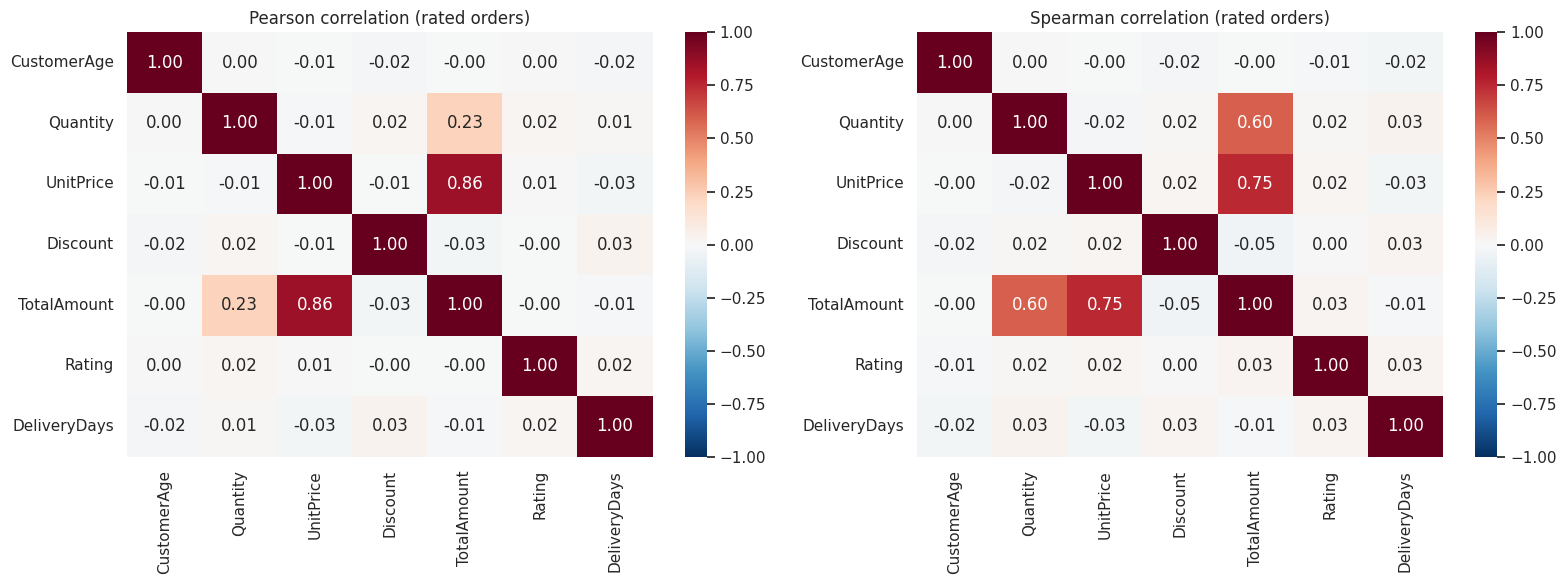

In [11]:
# ---- Measures of correlation: Pearson (linear) and Spearman (rank / monotonic) ----
corr_cols = ["CustomerAge", "Quantity", "UnitPrice", "Discount", "TotalAmount", "Rating", "DeliveryDays"]
pearson = rated[corr_cols].corr(method="pearson")
spearman = rated[corr_cols].corr(method="spearman")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pearson, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax[0]); ax[0].set_title("Pearson correlation (rated orders)")
sns.heatmap(spearman, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax[1]); ax[1].set_title("Spearman correlation (rated orders)")
plt.tight_layout(); plt.show()

### 4.4 Descriptive Statistics — Categorical Variables
Count, Frequency, Relative Frequency (Proportion) and the category with the highest / lowest frequency.

In [12]:
cat_summary = []
for c in CAT_COLS:
    vc = df[c].value_counts()
    print(f"\n===== {c} =====")
    display(pd.DataFrame({"Frequency": vc, "Relative Freq": (vc / vc.sum()).round(4),
                          "Percent": (vc / vc.sum() * 100).round(2)}))
    cat_summary.append({"Variable": c, "Levels": vc.size, "Count": int(vc.sum()),
                        "Highest": vc.idxmax(), "Highest Freq": int(vc.max()), "Highest %": round(vc.max()/vc.sum()*100, 2),
                        "Lowest": vc.idxmin(), "Lowest Freq": int(vc.min()), "Lowest %": round(vc.min()/vc.sum()*100, 2)})
print("\n===== SUMMARY: highest / lowest frequency categories =====")
cat_summary = pd.DataFrame(cat_summary); cat_summary


===== Gender =====


,Frequency,Relative Freq,Percent
Gender,,,
Male,1257,0.5028,50.2800
Female,1243,0.4972,49.7200



===== City =====


,Frequency,Relative Freq,Percent
City,,,
Cairo,957,0.3828,38.2800
Giza,486,0.1944,19.4400
Alexandria,440,0.1760,17.6000
Mansoura,268,0.1072,10.7200
Tanta,209,0.0836,8.3600
Aswan,140,0.0560,5.6000



===== Category =====


...

,Frequency,Relative Freq,Percent
AgeGroup,,,
36-45,492,0.1968,19.6800
56-65,491,0.1964,19.6400
26-35,484,0.1936,19.3600
46-55,465,0.1860,18.6000
18-25,367,0.1468,14.6800
66-80,201,0.0804,8.0400



===== DiscountPct =====


,Frequency,Relative Freq,Percent
DiscountPct,,,
0,880,0.3520,35.2000
10,641,0.2564,25.6400
5,482,0.1928,19.2800
15,380,0.1520,15.2000
20,117,0.0468,4.6800



===== SUMMARY: highest / lowest frequency categories =====


,Variable,Levels,Count,Highest,Highest Freq,Highest %,Lowest,Lowest Freq,Lowest %
0,Gender,2,2500,Male,1257,50.2800,Female,1243,49.7200
1,City,6,2500,Cairo,957,38.2800,Aswan,140,5.6000
2,Category,5,2500,Electronics,541,21.6400,Beauty,446,17.8400
3,Product,25,2500,Smart Watch,122,4.8800,Face Cream,84,3.3600
4,PaymentMethod,5,2500,Wallet,509,20.3600,Visa,488,19.5200
5,OrderStatus,3,2500,Delivered,1974,78.9600,Cancelled,241,9.6400
6,AgeGroup,6,2500,36-45,492,19.6800,66-80,201,8.0400
7,DiscountPct,5,2500,0,880,35.2000,20,117,4.6800


In [13]:
# Rating is ordinal: frequency table + median / mode
vc = rated.Rating.value_counts().sort_index()
print(pd.DataFrame({"Frequency": vc, "Relative Freq": (vc/vc.sum()).round(4)}))
print("\nMedian rating:", rated.Rating.median(), "| Mode:", rated.Rating.mode().iloc[0])

        Frequency  Relative Freq
Rating                          
1.0000         44         0.0226
2.0000        137         0.0704
3.0000        315         0.1618
4.0000        802         0.4119
5.0000        649         0.3333

Median rating: 4.0 | Mode: 4.0


### 4.5 Data Visualization
**Non-categorical:** Scatter, Line, Box-Whisker, Violin, Heat Map, Pair Plot. **Categorical:** Bar, Histogram, Pie.

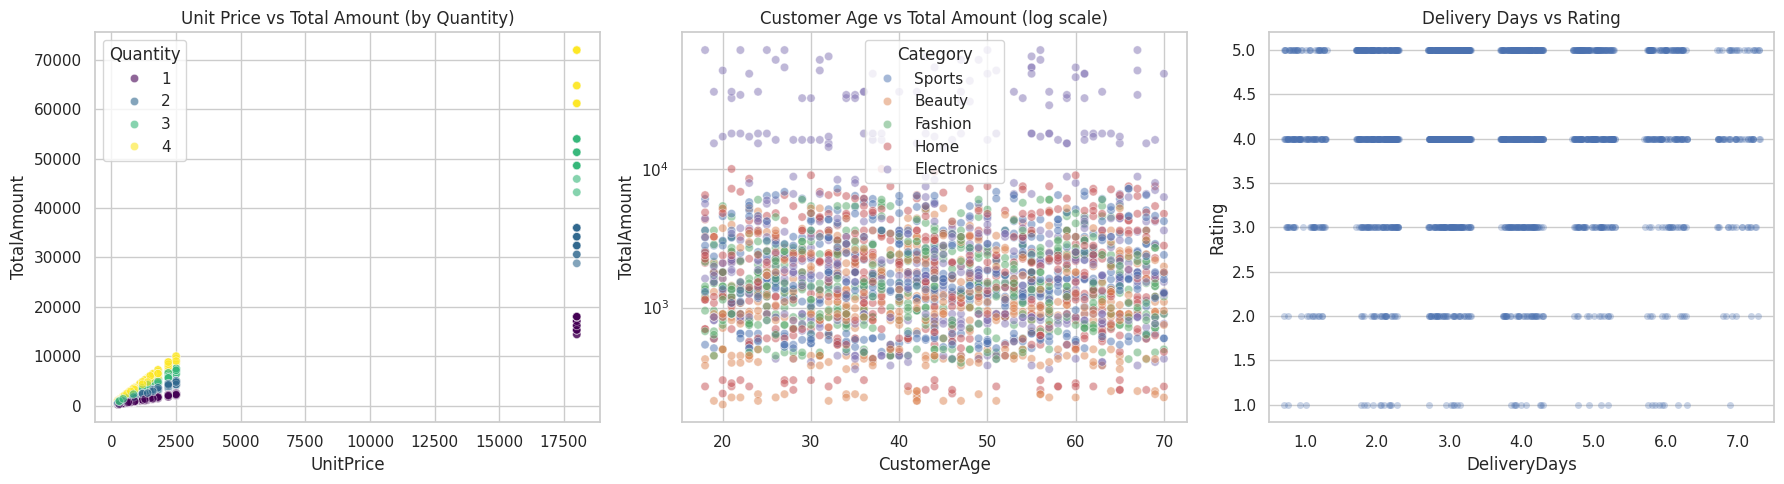

In [14]:
# ---- Scatter plots ----
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=df, x="UnitPrice", y="TotalAmount", hue="Quantity", palette="viridis", alpha=.6, ax=ax[0])
ax[0].set_title("Unit Price vs Total Amount (by Quantity)")
sns.scatterplot(data=df, x="CustomerAge", y="TotalAmount", hue="Category", alpha=.5, ax=ax[1]); ax[1].set_yscale("log")
ax[1].set_title("Customer Age vs Total Amount (log scale)")
sns.stripplot(data=rated, x="DeliveryDays", y="Rating", jitter=.3, alpha=.3, ax=ax[2]); ax[2].set_title("Delivery Days vs Rating")
plt.tight_layout(); plt.show()

,OrderMonth,Orders,Revenue,AvgOrderValue,CancelRate,AvgRating
0,2026-01,422,"1,563,232.5000","3,704.3424",0.0900,3.9323
1,2026-02,421,"1,333,435.0000","3,167.3040",0.0903,3.9970
2,2026-03,447,"1,471,560.0000","3,292.0805",0.1029,3.9705
3,2026-04,407,"1,293,645.0000","3,178.4889",0.1179,3.9871
4,2026-05,412,"1,331,970.0000","3,232.9369",0.0874,3.9116
5,2026-06,385,"1,398,532.5000","3,632.5519",0.0909,3.9771


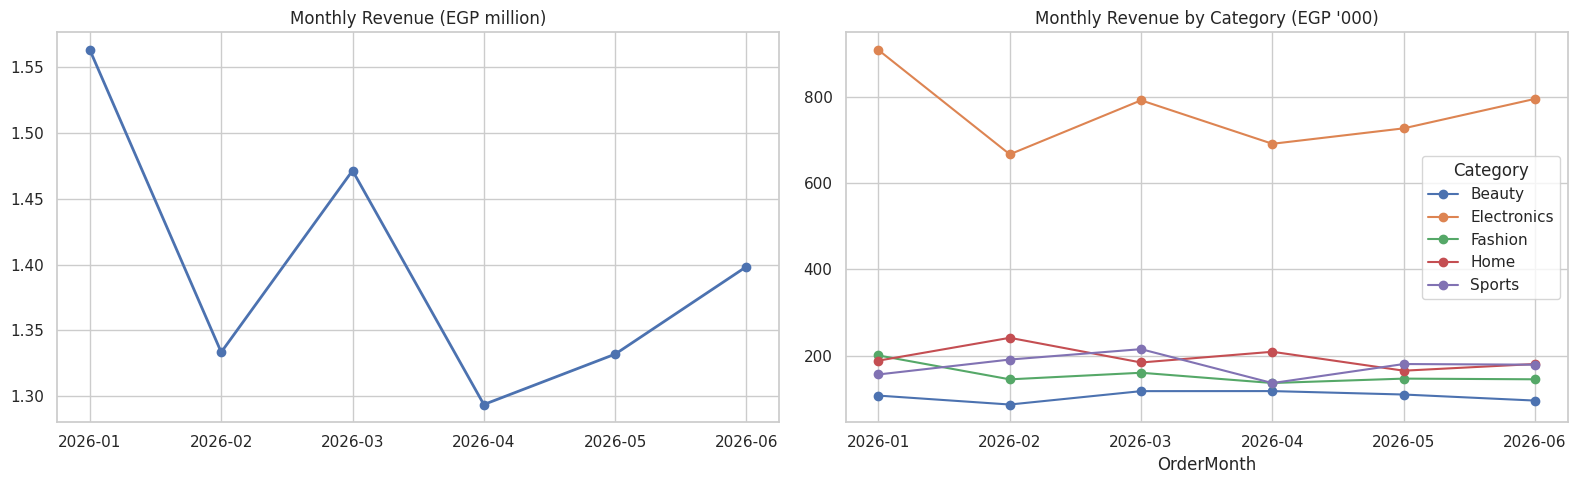

In [15]:
# ---- Line plots: monthly trend ----
monthly = df.dropna(subset=["OrderMonth"]).groupby("OrderMonth").agg(
    Orders=("OrderID", "count"), Revenue=("TotalAmount", "sum"),
    AvgOrderValue=("TotalAmount", "mean"), CancelRate=("IsCancelled", "mean"), AvgRating=("Rating", "mean")).reset_index()
display(monthly)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].plot(monthly.OrderMonth, monthly.Revenue / 1e6, marker="o", lw=2); ax[0].set_title("Monthly Revenue (EGP million)")
cat_month = df.dropna(subset=["OrderMonth"]).pivot_table(index="OrderMonth", columns="Category", values="TotalAmount", aggfunc="sum")
(cat_month / 1e3).plot(marker="o", ax=ax[1]); ax[1].set_title("Monthly Revenue by Category (EGP '000)")
plt.tight_layout(); plt.show()

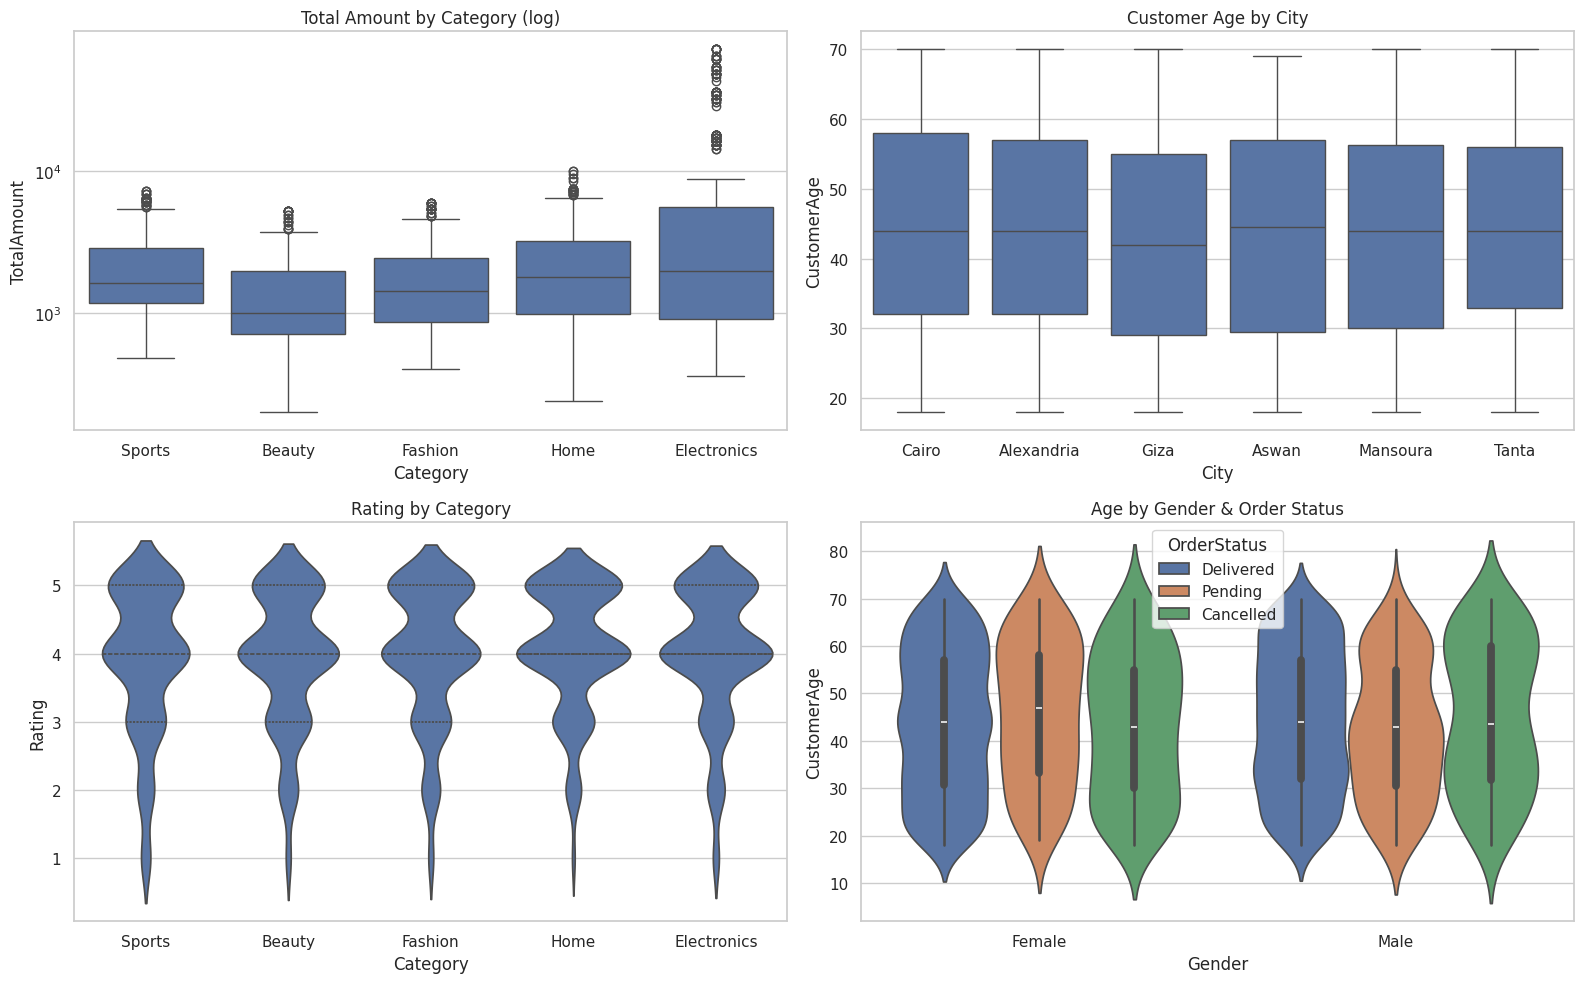

In [16]:
# ---- Box-whisker and violin plots ----
fig, ax = plt.subplots(2, 2, figsize=(16, 10))
sns.boxplot(data=df, x="Category", y="TotalAmount", ax=ax[0, 0]); ax[0, 0].set_yscale("log"); ax[0, 0].set_title("Total Amount by Category (log)")
sns.boxplot(data=df, x="City", y="CustomerAge", ax=ax[0, 1]); ax[0, 1].set_title("Customer Age by City")
sns.violinplot(data=rated, x="Category", y="Rating", inner="quartile", ax=ax[1, 0]); ax[1, 0].set_title("Rating by Category")
sns.violinplot(data=df, x="Gender", y="CustomerAge", hue="OrderStatus", split=False, ax=ax[1, 1]); ax[1, 1].set_title("Age by Gender & Order Status")
plt.tight_layout(); plt.show()

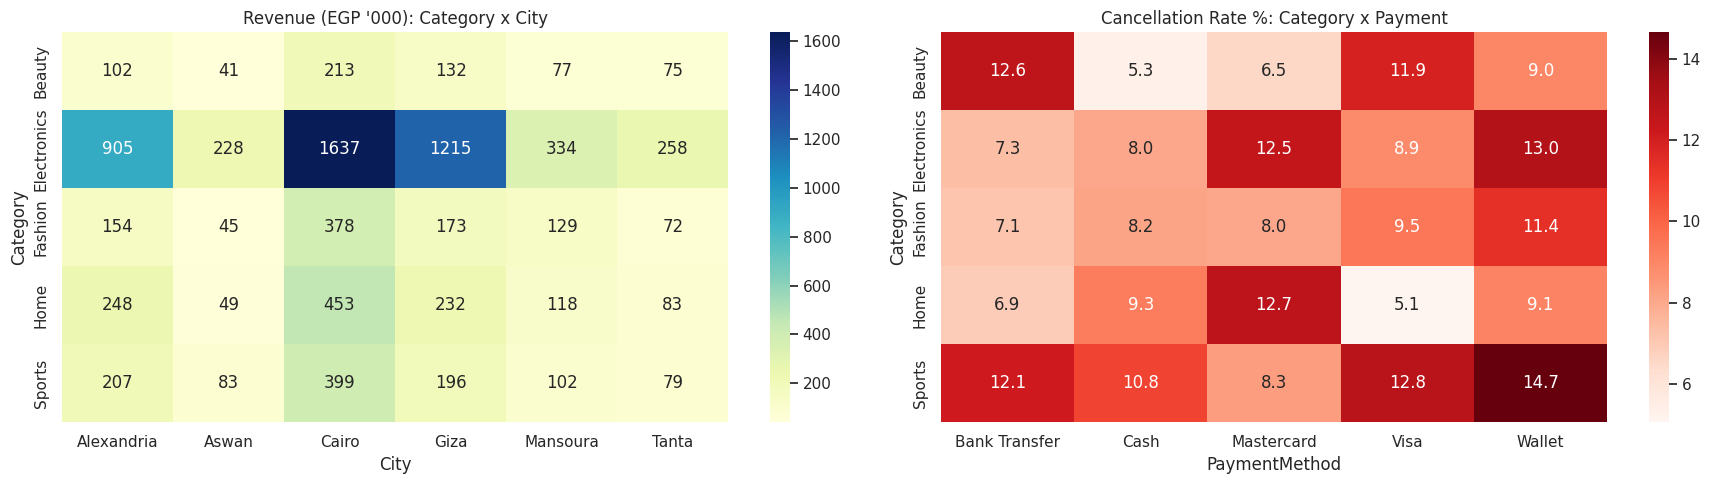

In [17]:
# ---- Heat maps: category x city revenue and cancellation rate ----
fig, ax = plt.subplots(1, 2, figsize=(18, 5))
sns.heatmap(df.pivot_table(index="Category", columns="City", values="TotalAmount", aggfunc="sum") / 1e3,
            annot=True, fmt=".0f", cmap="YlGnBu", ax=ax[0]); ax[0].set_title("Revenue (EGP '000): Category x City")
sns.heatmap(df.pivot_table(index="Category", columns="PaymentMethod", values="IsCancelled", aggfunc="mean") * 100,
            annot=True, fmt=".1f", cmap="Reds", ax=ax[1]); ax[1].set_title("Cancellation Rate %: Category x Payment")
plt.tight_layout(); plt.show()

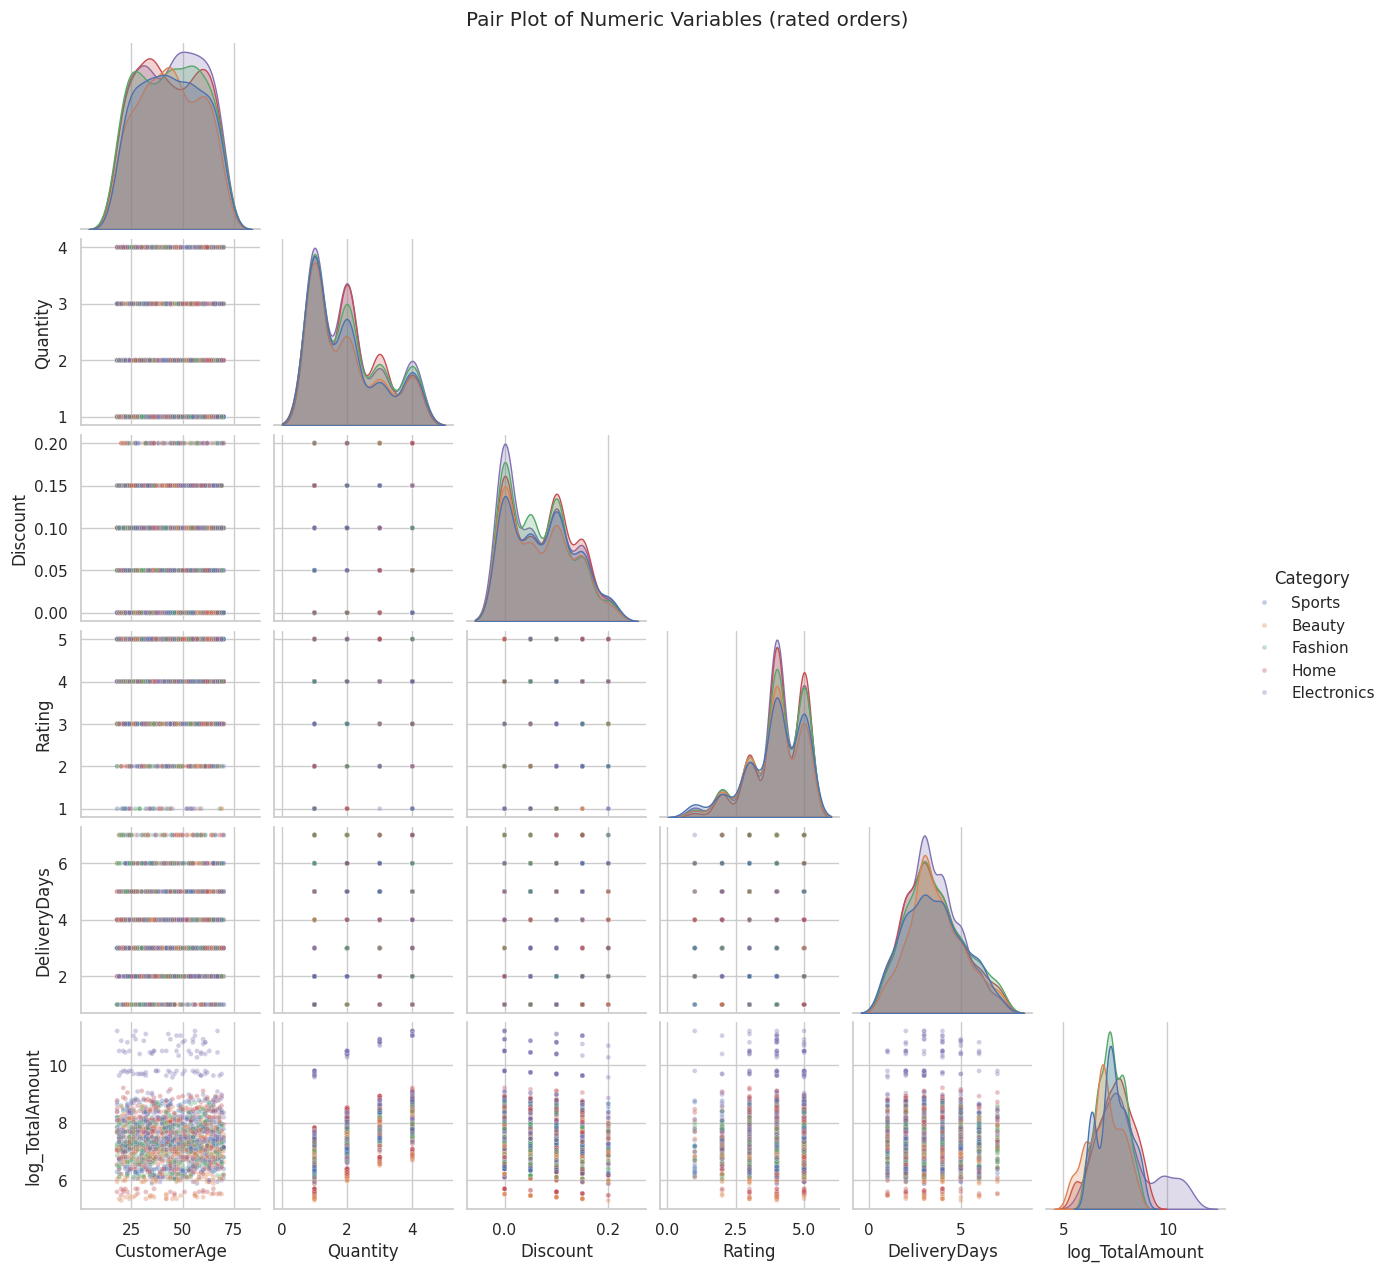

In [18]:
# ---- Pair plot ----
pp = rated[["CustomerAge", "Quantity", "Discount", "TotalAmount", "Rating", "DeliveryDays", "Category"]].copy()
pp["log_TotalAmount"] = np.log(pp.TotalAmount)
sns.pairplot(pp.drop(columns="TotalAmount"), hue="Category", corner=True, plot_kws={"alpha": .35, "s": 12}, height=2.1)
plt.suptitle("Pair Plot of Numeric Variables (rated orders)", y=1.01); plt.show()

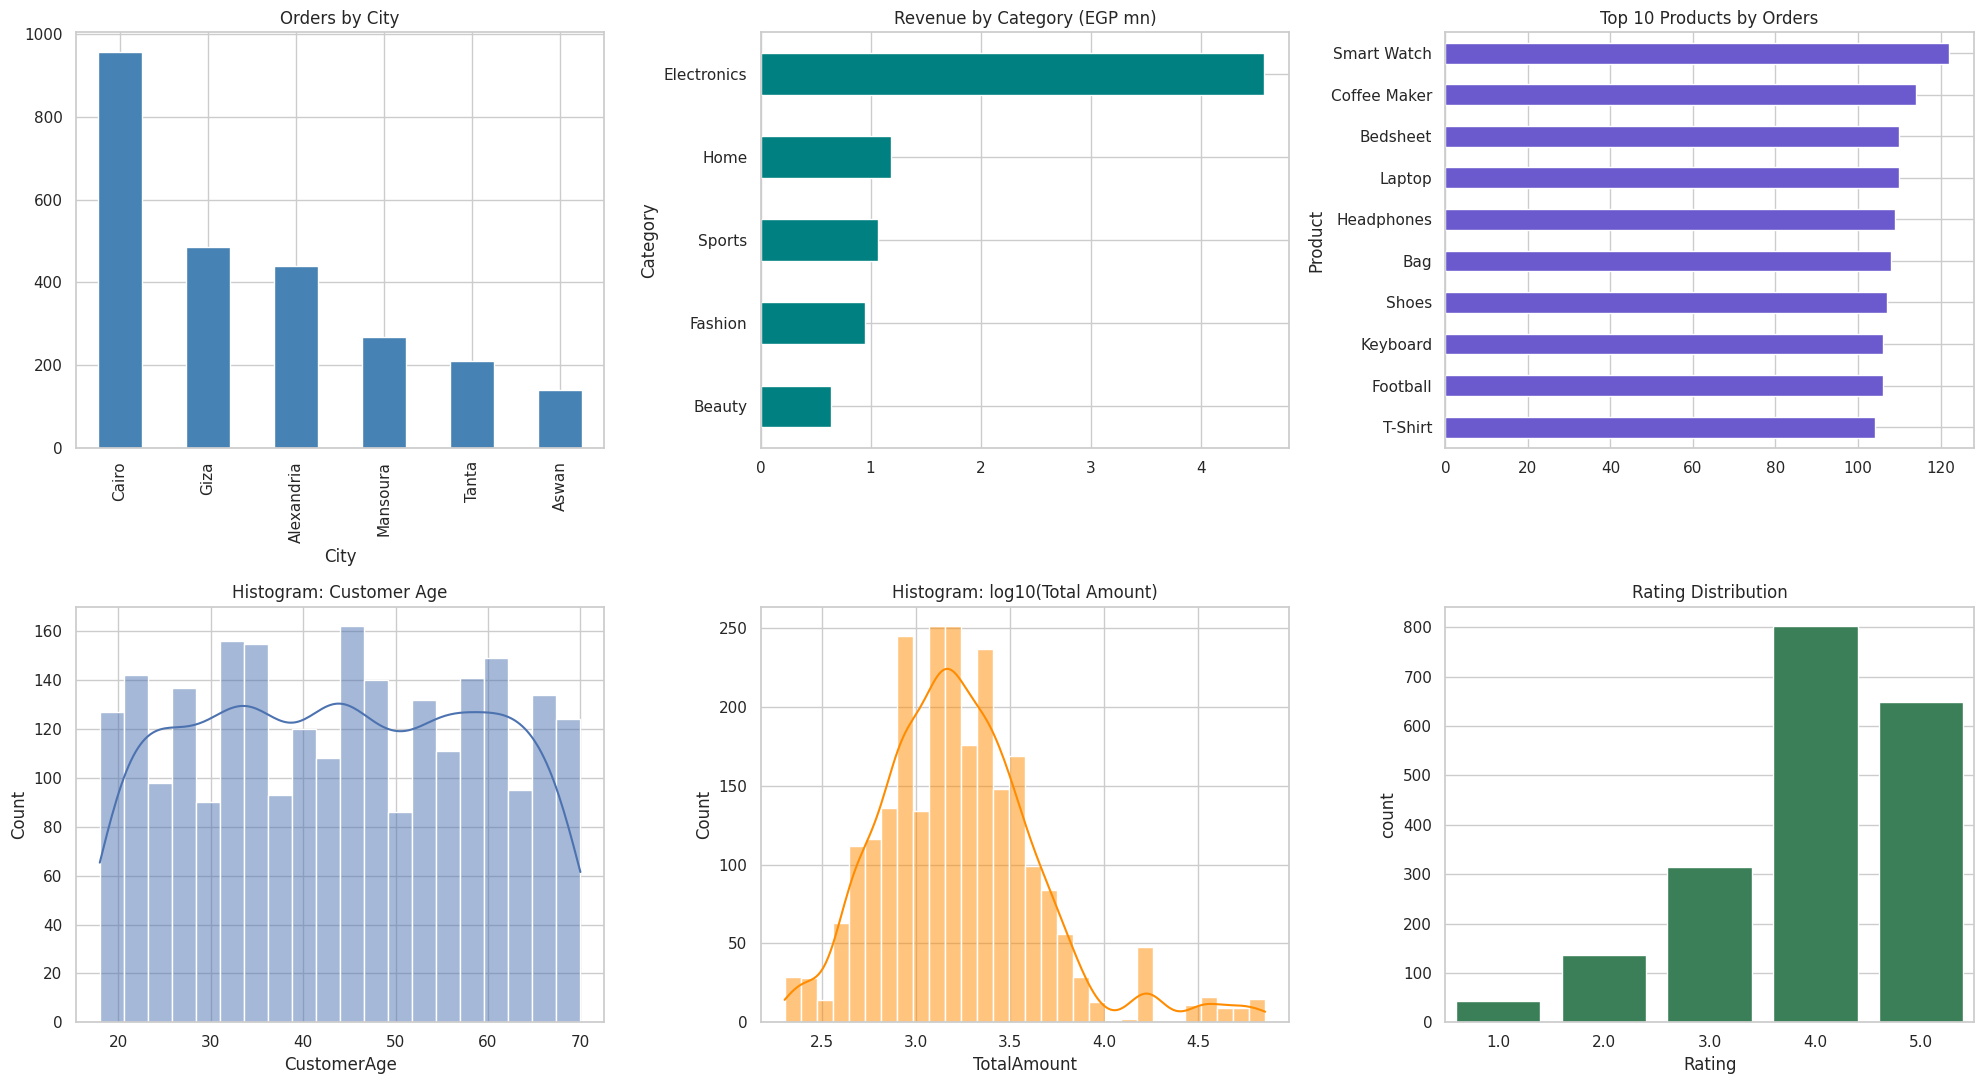

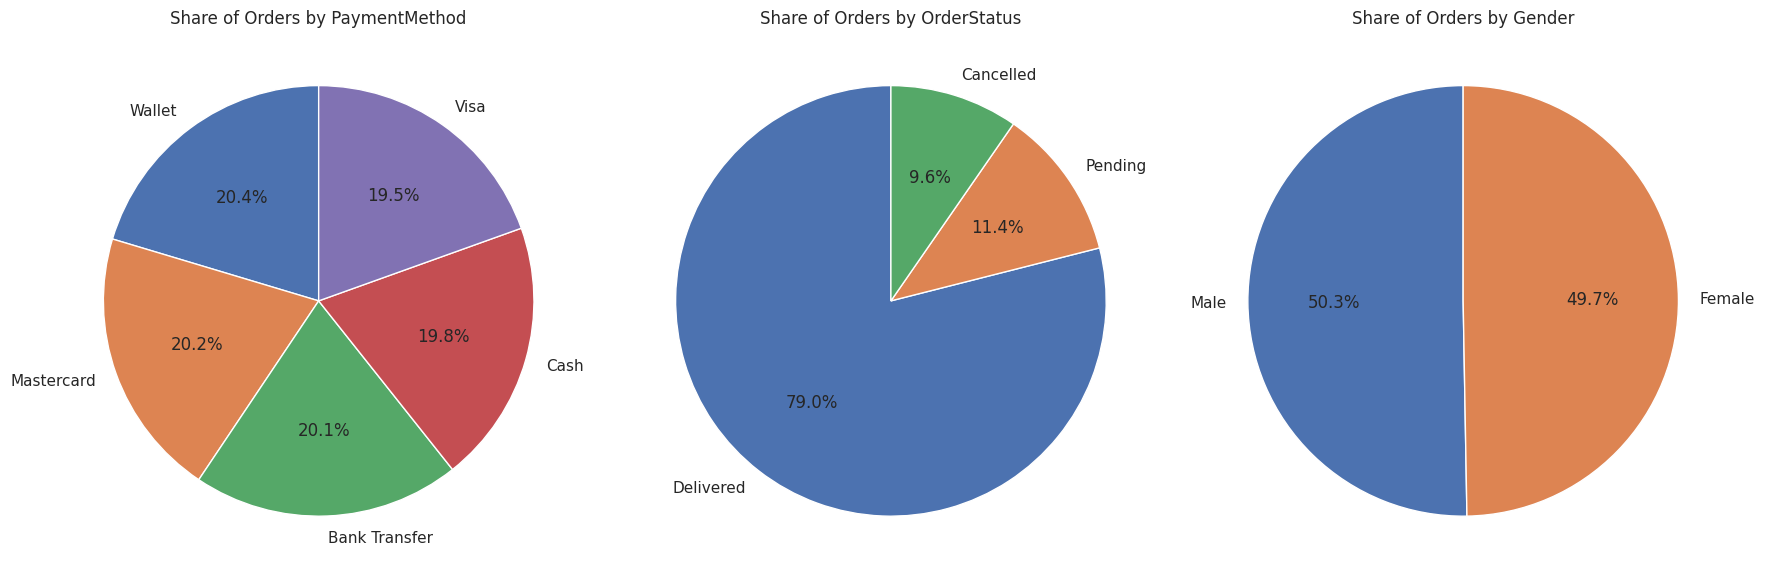

In [19]:
# ---- Categorical: bar plots, histograms, pie charts ----
fig, ax = plt.subplots(2, 3, figsize=(20, 11))
df.City.value_counts().plot.bar(ax=ax[0, 0], color="steelblue"); ax[0, 0].set_title("Orders by City")
df.groupby("Category").TotalAmount.sum().sort_values().div(1e6).plot.barh(ax=ax[0, 1], color="teal"); ax[0, 1].set_title("Revenue by Category (EGP mn)")
df.Product.value_counts().head(10).sort_values().plot.barh(ax=ax[0, 2], color="slateblue"); ax[0, 2].set_title("Top 10 Products by Orders")
sns.histplot(df.CustomerAge, bins=20, kde=True, ax=ax[1, 0]); ax[1, 0].set_title("Histogram: Customer Age")
sns.histplot(np.log10(df.TotalAmount), bins=30, kde=True, ax=ax[1, 1], color="darkorange"); ax[1, 1].set_title("Histogram: log10(Total Amount)")
sns.countplot(data=rated, x="Rating", ax=ax[1, 2], color="seagreen"); ax[1, 2].set_title("Rating Distribution")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
for a, col in zip(ax, ["PaymentMethod", "OrderStatus", "Gender"]):
    df[col].value_counts().plot.pie(autopct="%1.1f%%", startangle=90, ax=a); a.set_ylabel(""); a.set_title(f"Share of Orders by {col}")
plt.tight_layout(); plt.show()

### 4.6 Inferential Statistics
All tests use **α = 0.05**. Each result is stored in a summary table at the end of this section.

In [20]:
RESULTS = []
def record(test, variables, h0, stat, p, note=""):
    RESULTS.append({"Test": test, "Variables": variables, "H0": h0, "Statistic": round(float(stat), 4),
                    "p-value": float(p), "Decision (α=0.05)": "Reject H0" if p < ALPHA else "Fail to reject H0", "Note": note})
    print(f"{test:<32} | {variables:<38} | stat = {stat:>10.4f} | p = {p:.4g} | {'Reject H0' if p < ALPHA else 'Fail to reject H0'}")

#### (a) Confidence Intervals (95%)

In [21]:
def mean_ci(x, conf=.95):
    x = x.dropna(); m, se = x.mean(), stats.sem(x)
    lo, hi = stats.t.interval(conf, len(x) - 1, loc=m, scale=se); return m, lo, hi

ci_rows = []
for c, d in [("TotalAmount", df), ("CustomerAge", df), ("Rating", rated), ("DeliveryDays", delivered)]:
    m, lo, hi = mean_ci(d[c]); ci_rows.append([f"Mean {c}", m, lo, hi])
for label, k, n in [("Proportion Cancelled", df.IsCancelled.sum(), len(df)),
                    ("Proportion High Rating (4-5)", rated.HighRating.sum(), len(rated))]:
    lo, hi = proportion_confint(k, n, alpha=.05, method="wilson"); ci_rows.append([label, k / n, lo, hi])
for cat in df.Category.unique():
    m, lo, hi = mean_ci(df.loc[df.Category == cat, "TotalAmount"]); ci_rows.append([f"Mean TotalAmount – {cat}", m, lo, hi])
ci_table = pd.DataFrame(ci_rows, columns=["Parameter", "Estimate", "95% CI Lower", "95% CI Upper"]); ci_table

,Parameter,Estimate,95% CI Lower,95% CI Upper
0,Mean TotalAmount,"3,366.3320","3,066.8141","3,665.8499"
1,Mean CustomerAge,43.9052,43.3151,44.4953
2,Mean Rating,3.9630,3.9190,4.0070
3,Mean DeliveryDays,3.5500,3.4823,3.6177
4,Proportion Cancelled,0.0964,0.0854,0.1086
5,Proportion High Rating (4-5),0.7452,0.7254,0.7641
6,Mean TotalAmount – Sports,"2,183.7551","2,042.1724","2,325.3379"
7,Mean TotalAmount – Beauty,"1,436.6368","1,329.7542","1,543.5194"
8,Mean TotalAmount – Fashion,"1,819.7222","1,711.7565","1,927.6880"
9,Mean TotalAmount – Home,"2,351.2127","2,184.6538","2,517.7716"


#### (b) Test of Normality — Shapiro-Wilk, Kolmogorov-Smirnov, Anderson-Darling, Jarque-Bera

In [22]:
norm_rows = []
for c, d in [("TotalAmount", df), ("CustomerAge", df), ("Rating", rated), ("DeliveryDays", delivered)]:
    x = d[c].dropna()
    for name, series in [(c, x), (f"log({c})", np.log(x))] if c == "TotalAmount" else [(c, x)]:
        sw = stats.shapiro(series.sample(min(5000, len(series)), random_state=SEED))
        ks = stats.kstest((series - series.mean()) / series.std(), "norm")
        ad = stats.anderson(series, dist="norm")
        jb = stats.jarque_bera(series)
        norm_rows.append({"Variable": name, "Shapiro W": sw.statistic, "Shapiro p": sw.pvalue,
                          "KS D": ks.statistic, "KS p": ks.pvalue,
                          "AD stat": ad.statistic, "AD crit (5%)": ad.critical_values[2],
                          "JB stat": jb.statistic, "JB p": jb.pvalue,
                          "Normal?": "No" if (sw.pvalue < ALPHA or ad.statistic > ad.critical_values[2]) else "Yes"})
        record("Shapiro-Wilk normality", name, "Data is normally distributed", sw.statistic, sw.pvalue)
normality = pd.DataFrame(norm_rows); normality

Shapiro-Wilk normality           | TotalAmount                            | stat =     0.3326 | p = 6.827e-70 | Reject H0
Shapiro-Wilk normality           | log(TotalAmount)                       | stat =     0.9531 | p = 1.323e-27 | Reject H0
Shapiro-Wilk normality           | CustomerAge                            | stat =     0.9560 | p = 7.898e-27 | Reject H0
Shapiro-Wilk normality           | Rating                                 | stat =     0.8361 | p = 7.683e-41 | Reject H0
Shapiro-Wilk normality           | DeliveryDays                           | stat =     0.9407 | p = 3.034e-27 | Reject H0


,Variable,Shapiro W,Shapiro p,KS D,KS p,AD stat,AD crit (5%),JB stat,JB p,Normal?
0,TotalAmount,0.3326,0.0000,0.3394,0.0000,543.7585,0.7520,"185,324.1892",0.0000,No
1,log(TotalAmount),0.9531,0.0000,0.0625,0.0000,19.1532,0.7520,674.9998,0.0000,No
2,CustomerAge,0.9560,0.0000,0.0711,0.0000,27.2372,0.7520,146.7615,0.0000,No
3,Rating,0.8361,0.0000,0.2602,0.0000,119.3110,0.7520,293.0728,0.0000,No
4,DeliveryDays,0.9407,0.0000,0.1765,0.0000,43.0912,0.7520,62.8260,0.0000,No


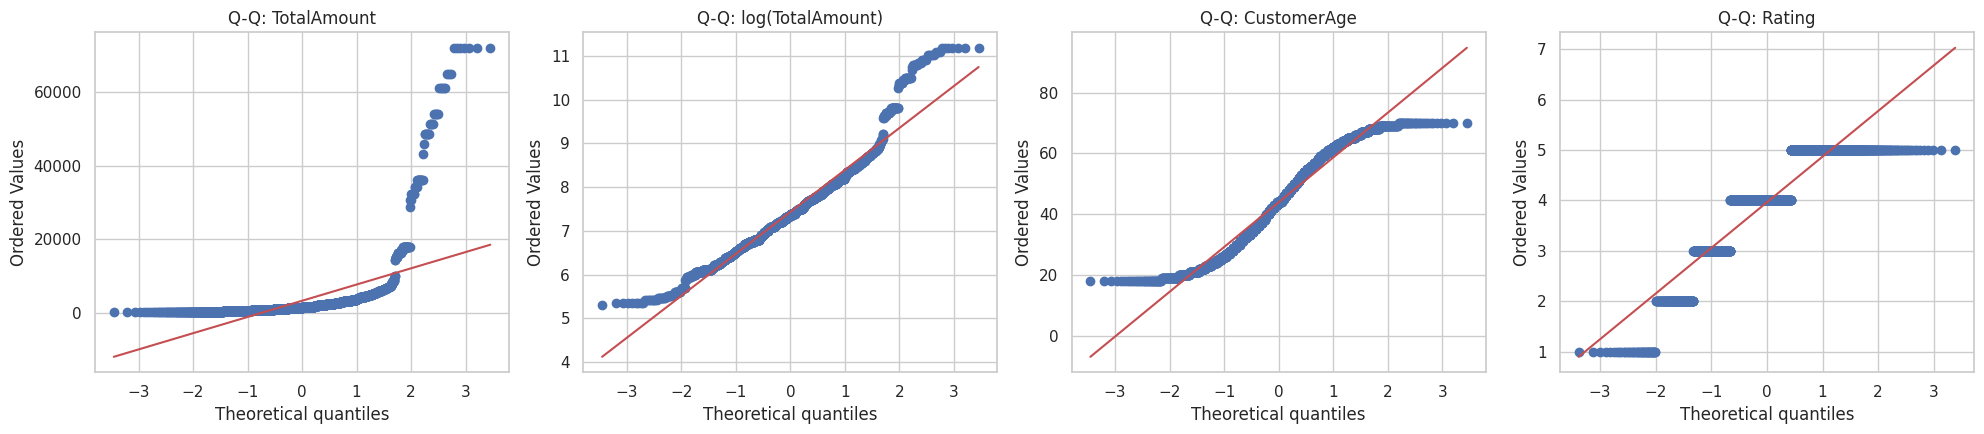

In [23]:
# Q-Q plots support the normality tests visually
fig, ax = plt.subplots(1, 4, figsize=(20, 4.5))
for a, (lbl, x) in zip(ax, [("TotalAmount", df.TotalAmount), ("log(TotalAmount)", np.log(df.TotalAmount)),
                            ("CustomerAge", df.CustomerAge), ("Rating", rated.Rating)]):
    stats.probplot(x, dist="norm", plot=a); a.set_title(f"Q-Q: {lbl}")
plt.tight_layout(); plt.show()

#### (c) Test of Mean — t-tests and ANOVA

In [24]:
m = df.loc[df.Gender == "Male", "TotalAmount"]; f = df.loc[df.Gender == "Female", "TotalAmount"]
t = stats.ttest_ind(m, f, equal_var=False)
record("Welch two-sample t-test", "TotalAmount: Male vs Female", "Mean spend equal", t.statistic, t.pvalue)

t1 = stats.ttest_1samp(rated.Rating, 4.0)
record("One-sample t-test", "Rating vs target 4.0", "Mean rating = 4.0", t1.statistic, t1.pvalue)

rm = rated.loc[rated.Gender == "Male", "Rating"]; rf = rated.loc[rated.Gender == "Female", "Rating"]
t2 = stats.ttest_ind(rm, rf, equal_var=False)
record("Welch two-sample t-test", "Rating: Male vs Female", "Mean rating equal", t2.statistic, t2.pvalue)

# Paired t-test: gross value (Qty x Price) vs net value paid, discounted orders only
disc_orders = df[df.Discount > 0]
tp = stats.ttest_rel(disc_orders.Quantity * disc_orders.UnitPrice, disc_orders.TotalAmount)
record("Paired t-test", "Gross vs Net amount (discounted)", "No difference", tp.statistic, tp.pvalue)

Welch two-sample t-test          | TotalAmount: Male vs Female            | stat =    -0.3723 | p = 0.7097 | Fail to reject H0
One-sample t-test                | Rating vs target 4.0                   | stat =    -1.6491 | p = 0.0993 | Fail to reject H0
Welch two-sample t-test          | Rating: Male vs Female                 | stat =     1.3556 | p = 0.1754 | Fail to reject H0
Paired t-test                    | Gross vs Net amount (discounted)       | stat =    16.0206 | p = 9.874e-54 | Reject H0


In [25]:
# One-way ANOVA
groups = [g.TotalAmount.values for _, g in df.groupby("Category")]
a1 = stats.f_oneway(*groups); record("One-way ANOVA", "TotalAmount across Category", "All category means equal", a1.statistic, a1.pvalue)
groups = [g.Rating.values for _, g in rated.groupby("Category")]
a2 = stats.f_oneway(*groups); record("One-way ANOVA", "Rating across Category", "All category means equal", a2.statistic, a2.pvalue)
groups = [g.TotalAmount.values for _, g in df.groupby("City")]
a3 = stats.f_oneway(*groups); record("One-way ANOVA", "TotalAmount across City", "All city means equal", a3.statistic, a3.pvalue)
groups = [g.Rating.values for _, g in rated.groupby("DeliveryDays")]
a4 = stats.f_oneway(*groups); record("One-way ANOVA", "Rating across DeliveryDays", "All means equal", a4.statistic, a4.pvalue)

# Two-way ANOVA (statsmodels): TotalAmount ~ Category x Gender
aov2 = sm.stats.anova_lm(smf.ols("np.log(TotalAmount) ~ C(Category) * C(Gender)", data=df).fit(), typ=2)
print("\nTwo-way ANOVA on log(TotalAmount):"); display(aov2)

One-way ANOVA                    | TotalAmount across Category            | stat =    88.6986 | p = 1.444e-70 | Reject H0
One-way ANOVA                    | Rating across Category                 | stat =     2.0441 | p = 0.08577 | Fail to reject H0
One-way ANOVA                    | TotalAmount across City                | stat =     1.4814 | p = 0.1925 | Fail to reject H0
One-way ANOVA                    | Rating across DeliveryDays             | stat =     1.1819 | p = 0.313 | Fail to reject H0

Two-way ANOVA on log(TotalAmount):


,sum_sq,df,F,PR(>F)
C(Category),259.2327,4.0000,75.3379,0.0000
C(Gender),0.5347,1.0000,0.6215,0.4305
C(Category):C(Gender),2.2846,4.0000,0.6639,0.6170
Residual,"2,141.9804","2,490.0000",NaN,NaN


#### (d) Test of Variance — F-test, Levene, Bartlett

In [26]:
# F-test for equality of two variances (log TotalAmount, Male vs Female)
lm_, lf_ = np.log(m), np.log(f)
F = lm_.var(ddof=1) / lf_.var(ddof=1); d1, d2 = len(lm_) - 1, len(lf_) - 1
pF = 2 * min(stats.f.cdf(F, d1, d2), 1 - stats.f.cdf(F, d1, d2))
record("F-test (two variances)", "log(TotalAmount): Male vs Female", "Variances equal", F, pF)

lev = stats.levene(*[g.TotalAmount for _, g in df.groupby("Category")])
record("Levene test", "TotalAmount across Category", "Variances equal", lev.statistic, lev.pvalue)
bar = stats.bartlett(*[np.log(g.TotalAmount) for _, g in df.groupby("Category")])
record("Bartlett test", "log(TotalAmount) across Category", "Variances equal", bar.statistic, bar.pvalue)
lev2 = stats.levene(*[g.Rating for _, g in rated.groupby("Category")])
record("Levene test", "Rating across Category", "Variances equal", lev2.statistic, lev2.pvalue)

F-test (two variances)           | log(TotalAmount): Male vs Female       | stat =     0.9553 | p = 0.4187 | Fail to reject H0
Levene test                      | TotalAmount across Category            | stat =    87.2784 | p = 1.716e-69 | Reject H0
Bartlett test                    | log(TotalAmount) across Category       | stat =   384.8638 | p = 5.181e-82 | Reject H0
Levene test                      | Rating across Category                 | stat =     1.5892 | p = 0.1745 | Fail to reject H0


#### (e) Test of Proportion — z-test and Chi-square

In [27]:
# Two-proportion z-test: cancellation rate Male vs Female
ct = df.groupby("Gender").IsCancelled.agg(["sum", "count"]); display(ct.assign(rate=ct["sum"] / ct["count"]))
z, pz = proportions_ztest(ct["sum"].values, ct["count"].values)
record("Two-proportion z-test", "Cancel rate: Male vs Female", "Proportions equal", z, pz)

# One-proportion z-test: is the cancellation rate different from a 10% benchmark?
z1, pz1 = proportions_ztest(df.IsCancelled.sum(), len(df), value=0.10)
record("One-proportion z-test", "Cancel rate vs 10% benchmark", "p = 0.10", z1, pz1)

# Chi-square test of proportions: high-rating share across categories
tab = pd.crosstab(rated.Category, rated.HighRating); chi = stats.chi2_contingency(tab)
record("Chi-square (k proportions)", "High-rating share across Category", "Proportions equal", chi.statistic, chi.pvalue)

,sum,count,rate
Gender,,,
Female,133,1243,0.1070
Male,108,1257,0.0859


Two-proportion z-test            | Cancel rate: Male vs Female            | stat =     1.7856 | p = 0.07416 | Fail to reject H0
One-proportion z-test            | Cancel rate vs 10% benchmark           | stat =    -0.6099 | p = 0.5419 | Fail to reject H0
Chi-square (k proportions)       | High-rating share across Category      | stat =     7.9623 | p = 0.09297 | Fail to reject H0


#### (f) Test of Correlation — t-test on Pearson r

In [28]:
def corr_t_test(x, y, label):
    r = np.corrcoef(x, y)[0, 1]; n = len(x); t = r * np.sqrt((n - 2) / (1 - r**2))
    p = 2 * (1 - stats.t.cdf(abs(t), n - 2))
    record("Correlation t-test", f"{label} (r={r:.3f})", "ρ = 0", t, p)
corr_t_test(rated.DeliveryDays.fillna(rated.DeliveryDays.median()), rated.Rating, "DeliveryDays vs Rating")
corr_t_test(rated.Discount, rated.Rating, "Discount vs Rating")
corr_t_test(df.CustomerAge, df.TotalAmount, "Age vs TotalAmount")
corr_t_test(df.Quantity, df.TotalAmount, "Quantity vs TotalAmount")
sp = stats.spearmanr(df.UnitPrice, df.TotalAmount)
record("Spearman correlation test", f"UnitPrice vs TotalAmount (ρ={sp.statistic:.3f})", "ρs = 0", sp.statistic, sp.pvalue)

Correlation t-test               | DeliveryDays vs Rating (r=0.019)       | stat =     0.8461 | p = 0.3976 | Fail to reject H0
Correlation t-test               | Discount vs Rating (r=-0.002)          | stat =    -0.0951 | p = 0.9242 | Fail to reject H0
Correlation t-test               | Age vs TotalAmount (r=-0.003)          | stat =    -0.1719 | p = 0.8636 | Fail to reject H0
Correlation t-test               | Quantity vs TotalAmount (r=0.237)      | stat =    12.1850 | p = 0 | Reject H0
Spearman correlation test        | UnitPrice vs TotalAmount (ρ=0.754)     | stat =     0.7544 | p = 0 | Reject H0


#### (g) Chi-square Tests — Goodness of Fit and Test of Independence

In [29]:
for col in ["Category", "PaymentMethod", "Gender"]:
    obs = df[col].value_counts(); gof = stats.chisquare(obs)
    record("Chi-sq goodness of fit", f"{col} uniform?", "All levels equally likely", gof.statistic, gof.pvalue)
# GOF of rating against an assumed benchmark distribution (10%,10%,20%,30%,30%)
obs = rated.Rating.value_counts().sort_index(); exp = np.array([.10, .10, .20, .30, .30]) * obs.sum()
g2 = stats.chisquare(obs, exp); record("Chi-sq goodness of fit", "Rating vs benchmark 10/10/20/30/30", "Fits benchmark", g2.statistic, g2.pvalue)

for a, b, d in [("Category", "OrderStatus", df), ("PaymentMethod", "OrderStatus", df), ("Gender", "Category", df),
                ("City", "PaymentMethod", df), ("AgeGroup", "Category", df), ("Category", "Rating", rated)]:
    tab = pd.crosstab(d[a], d[b]); res = stats.chi2_contingency(tab)
    n = tab.values.sum(); cv = np.sqrt(res.statistic / (n * (min(tab.shape) - 1)))
    record("Chi-sq independence", f"{a} x {b}", "Variables independent", res.statistic, res.pvalue, f"Cramér's V = {cv:.3f}")
print("\nContingency table: Category x OrderStatus"); pd.crosstab(df.Category, df.OrderStatus, margins=True)

Chi-sq goodness of fit           | Category uniform?                      | stat =    10.4680 | p = 0.03324 | Reject H0
Chi-sq goodness of fit           | PaymentMethod uniform?                 | stat =     0.5800 | p = 0.9653 | Fail to reject H0
Chi-sq goodness of fit           | Gender uniform?                        | stat =     0.0784 | p = 0.7795 | Fail to reject H0
Chi-sq goodness of fit           | Rating vs benchmark 10/10/20/30/30     | stat =   236.4575 | p = 5.374e-50 | Reject H0
Chi-sq independence              | Category x OrderStatus                 | stat =     5.9517 | p = 0.6526 | Fail to reject H0
Chi-sq independence              | PaymentMethod x OrderStatus            | stat =    10.0135 | p = 0.2641 | Fail to reject H0
Chi-sq independence              | Gender x Category                      | stat =     1.5974 | p = 0.8093 | Fail to reject H0
Chi-sq independence              | City x PaymentMethod                   | stat =    12.1377 | p = 0.9113 | Fail to reject

OrderStatus,Cancelled,Delivered,Pending,All
Category,,,,
Beauty,40,354,52,446
Electronics,53,427,61,541
Fashion,46,410,66,522
Home,44,409,50,503
Sports,58,374,56,488
All,241,1974,285,2500


#### (h) Non-Parametric Tests — Mann-Whitney, Wilcoxon, Kruskal-Wallis, Friedman

In [30]:
mw = stats.mannwhitneyu(m, f); record("Mann-Whitney U", "TotalAmount: Male vs Female", "Same distribution", mw.statistic, mw.pvalue)
mw2 = stats.mannwhitneyu(rm, rf); record("Mann-Whitney U", "Rating: Male vs Female", "Same distribution", mw2.statistic, mw2.pvalue)

w = stats.wilcoxon(rated.Rating - 4); record("Wilcoxon signed-rank", "Rating vs median 4", "Median = 4", w.statistic, w.pvalue)
w2 = stats.wilcoxon(disc_orders.Quantity * disc_orders.UnitPrice, disc_orders.TotalAmount)
record("Wilcoxon signed-rank (paired)", "Gross vs Net amount (discounted)", "No difference", w2.statistic, w2.pvalue)

kw = stats.kruskal(*[g.TotalAmount for _, g in df.groupby("Category")])
record("Kruskal-Wallis H", "TotalAmount across Category", "Same distribution", kw.statistic, kw.pvalue)
kw2 = stats.kruskal(*[g.Rating for _, g in rated.groupby("Category")])
record("Kruskal-Wallis H", "Rating across Category", "Same distribution", kw2.statistic, kw2.pvalue)
kw3 = stats.kruskal(*[g.Rating for _, g in rated.groupby("PaymentMethod")])
record("Kruskal-Wallis H", "Rating across PaymentMethod", "Same distribution", kw3.statistic, kw3.pvalue)

# Friedman: repeated measures — the 6 months are blocks, the 5 categories are treatments (monthly revenue)
fr_tab = df.dropna(subset=["OrderMonth"]).pivot_table(index="OrderMonth", columns="Category", values="TotalAmount", aggfunc="sum")
fr = stats.friedmanchisquare(*[fr_tab[c] for c in fr_tab.columns])
record("Friedman test", "Monthly revenue across Category", "Same distribution", fr.statistic, fr.pvalue)
fr_tab2 = df.dropna(subset=["OrderMonth"]).pivot_table(index="OrderMonth", columns="Category", values="OrderID", aggfunc="count")
fr2 = stats.friedmanchisquare(*[fr_tab2[c] for c in fr_tab2.columns])
record("Friedman test", "Monthly order count across Category", "Same distribution", fr2.statistic, fr2.pvalue)

Mann-Whitney U                   | TotalAmount: Male vs Female            | stat = 804632.5000 | p = 0.1946 | Fail to reject H0
Mann-Whitney U                   | Rating: Male vs Female                 | stat = 494466.5000 | p = 0.0761 | Fail to reject H0
Wilcoxon signed-rank             | Rating vs median 4                     | stat = 313142.5000 | p = 0.1489 | Fail to reject H0
Wilcoxon signed-rank (paired)    | Gross vs Net amount (discounted)       | stat =     0.0000 | p = 2.447e-266 | Reject H0
Kruskal-Wallis H                 | TotalAmount across Category            | stat =   163.7779 | p = 2.262e-34 | Reject H0
Kruskal-Wallis H                 | Rating across Category                 | stat =     6.6558 | p = 0.1552 | Fail to reject H0
Kruskal-Wallis H                 | Rating across PaymentMethod            | stat =     2.8373 | p = 0.5854 | Fail to reject H0


Friedman test                    | Monthly revenue across Category        | stat =    20.4000 | p = 0.0004163 | Reject H0
Friedman test                    | Monthly order count across Category    | stat =     5.4790 | p = 0.2416 | Fail to reject H0


In [31]:
test_summary = pd.DataFrame(RESULTS)
test_summary["p-value"] = test_summary["p-value"].map(lambda p: f"{p:.4g}")
print(f"{len(test_summary)} hypothesis tests run | significant: {(test_summary['Decision (α=0.05)'] == 'Reject H0').sum()}")
test_summary

44 hypothesis tests run | significant: 16


,Test,Variables,H0,Statistic,p-value,Decision (α=0.05),Note
0,Shapiro-Wilk normality,TotalAmount,Data is normally distributed,0.3326,6.827e-70,Reject H0,
1,Shapiro-Wilk normality,log(TotalAmount),Data is normally distributed,0.9531,1.323e-27,Reject H0,
2,Shapiro-Wilk normality,CustomerAge,Data is normally distributed,0.9560,7.898e-27,Reject H0,
3,Shapiro-Wilk normality,Rating,Data is normally distributed,0.8361,7.683e-41,Reject H0,
4,Shapiro-Wilk normality,DeliveryDays,Data is normally distributed,0.9407,3.034e-27,Reject H0,
5,Welch two-sample t-test,TotalAmount: Male vs Female,Mean spend equal,-0.3723,0.7097,Fail to reject H0,
6,One-sample t-test,Rating vs target 4.0,Mean rating = 4.0,-1.6491,0.0993,Fail to reject H0,
7,Welch two-sample t-test,Rating: Male vs Female,Mean rating equal,1.3556,0.1754,Fail to reject H0,
8,Paired t-test,Gross vs Net amount (discounted),No difference,16.0206,9.874e-54,Reject H0,
9,One-way ANOVA,TotalAmount across Category,All category means equal,88.6986,1.444e-70,Reject H0,


### 4.7 Causal Analysis — Regression Models
1. **Multiple linear regression (cross-sectional):** drivers of order value
2. **Time-series regression:** trend in daily revenue
3. **Polynomial regression (cross-sectional):** non-linear effect of delivery time / age
4. **Regression with categorical variables:** what explains rating and order value
5. **Logistic regression:** probability of a high rating and of cancellation

In [32]:
# (1) Multiple linear regression — log-linear model of order value
m1 = smf.ols("np.log(TotalAmount) ~ Quantity + np.log(UnitPrice) + Discount + CustomerAge", data=df).fit()
print(m1.summary())
print("\nInterpretation: coefficient on Discount x 0.01 ≈ % change in order value per +1 pp discount;"
      " log(UnitPrice) coefficient is an elasticity.")

                             OLS Regression Results                            
Dep. Variable:     np.log(TotalAmount)   R-squared:                       0.989
Model:                             OLS   Adj. R-squared:                  0.989
Method:                  Least Squares   F-statistic:                 5.477e+04
Date:                 Sun, 27 Sep 2026   Prob (F-statistic):               0.00
Time:                         12:20:59   Log-Likelihood:                 2109.6
No. Observations:                 2500   AIC:                            -4209.
Df Residuals:                     2495   BIC:                            -4180.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -0.4016

Levels model: R² = 0.784 | Adj R² = 0.783


,coef,p-value
Intercept,"-3,153.9109",0.0000
Quantity,"1,733.0423",0.0000
UnitPrice,1.8513,0.0000
Discount,"-3,522.5406",0.0023
CustomerAge,-1.2422,0.7926


VIF:

 {'Quantity': np.float64(1.0), 'UnitPrice': np.float64(1.0), 'Discount': np.float64(1.0), 'CustomerAge': np.float64(1.0)}


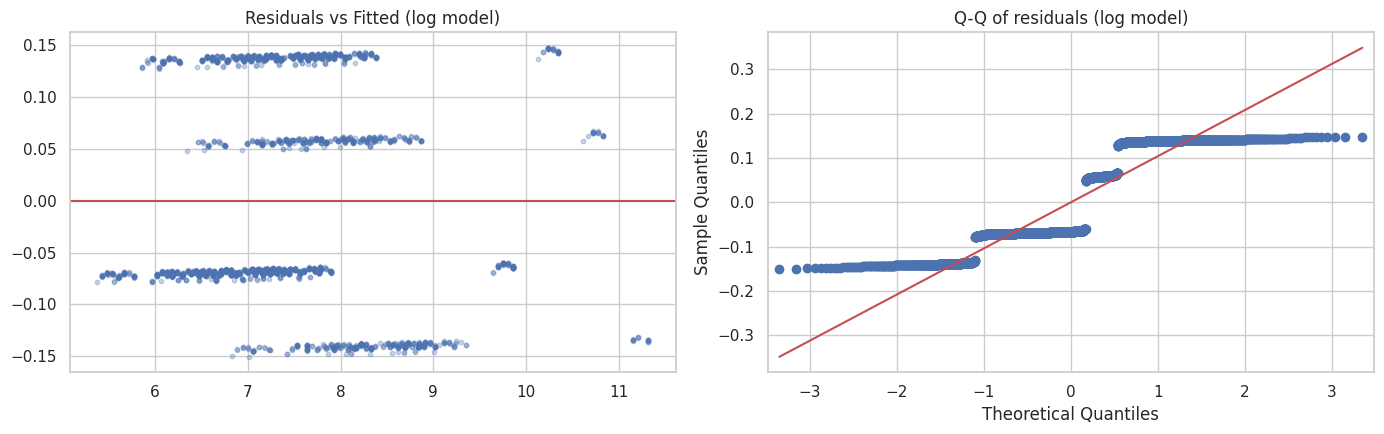

In [33]:
# Linear model in levels (for direct EGP interpretation) with diagnostic plots
m1b = smf.ols("TotalAmount ~ Quantity + UnitPrice + Discount + CustomerAge", data=df).fit()
print(f"Levels model: R² = {m1b.rsquared:.3f} | Adj R² = {m1b.rsquared_adj:.3f}")
display(pd.DataFrame({"coef": m1b.params, "p-value": m1b.pvalues}))
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = sm.add_constant(df[["Quantity", "UnitPrice", "Discount", "CustomerAge"]])
print("VIF:", {c: round(variance_inflation_factor(X.values, i), 2) for i, c in enumerate(X.columns) if c != "const"})
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].scatter(m1.fittedvalues, m1.resid, alpha=.3, s=10); ax[0].axhline(0, c="r"); ax[0].set_title("Residuals vs Fitted (log model)")
sm.qqplot(m1.resid, line="s", ax=ax[1]); ax[1].set_title("Q-Q of residuals (log model)")
plt.tight_layout(); plt.show()

                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              15.0702      0.820     18.384      0.000      13.452      16.688
C(DOW)[T.Monday]       -1.4768      0.973     -1.517      0.131      -3.398       0.444
C(DOW)[T.Saturday]     -0.1846      0.973     -0.190      0.850      -2.105       1.736
C(DOW)[T.Sunday]       -0.4076      0.973     -0.419      0.676      -2.328       1.513
C(DOW)[T.Thursday]     -1.6231      0.973     -1.668      0.097      -3.544       0.298
C(DOW)[T.Tuesday]       0.0593      0.983      0.060      0.952      -1.881       1.999
C(DOW)[T.Wednesday]     0.0270      0.983      0.027      0.978      -1.913       1.967
t                      -0.0077      0.005     -1.539      0.126      -0.018       0.002

Orders trend model R² = 0.050
Revenue trend: slope = -35.4 EGP/day, p = 0.438, R² = 0.003
Durbin-Watson (autocorrelatio

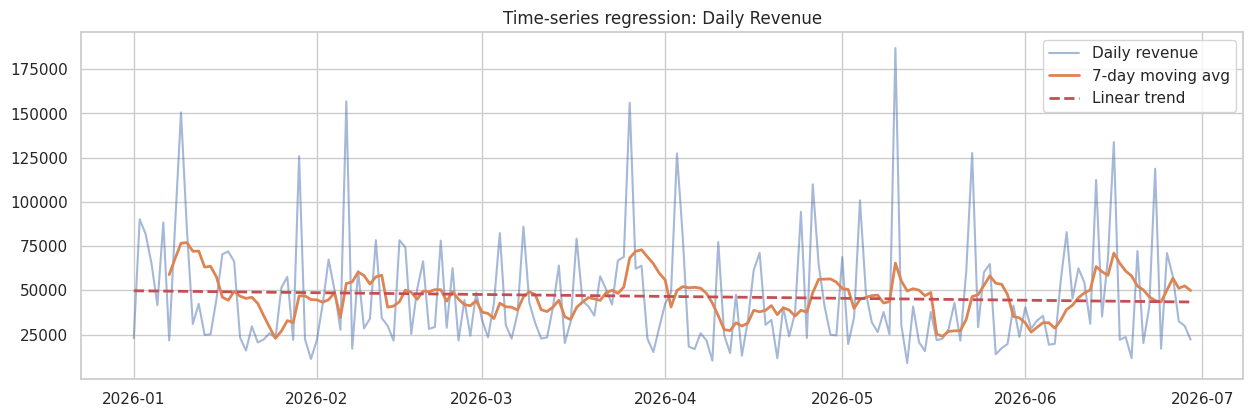

In [34]:
# (2) Time-series regression: daily revenue on a time trend + day-of-week effects
daily = df.dropna(subset=["OrderDate"]).set_index("OrderDate").resample("D").agg(
    Revenue=("TotalAmount", "sum"), Orders=("OrderID", "count")).reset_index()
daily["t"] = np.arange(len(daily)); daily["DOW"] = daily.OrderDate.dt.day_name()
m2 = smf.ols("Orders ~ t + C(DOW)", data=daily).fit()
m2r = smf.ols("Revenue ~ t", data=daily).fit()
print(m2.summary().tables[1]); print(f"\nOrders trend model R² = {m2.rsquared:.3f}")
print(f"Revenue trend: slope = {m2r.params['t']:.1f} EGP/day, p = {m2r.pvalues['t']:.3f}, R² = {m2r.rsquared:.3f}")
from statsmodels.stats.stattools import durbin_watson
print("Durbin-Watson (autocorrelation check):", round(durbin_watson(m2r.resid), 3))
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(daily.OrderDate, daily.Revenue, alpha=.5, label="Daily revenue")
ax.plot(daily.OrderDate, daily.Revenue.rolling(7).mean(), lw=2, label="7-day moving avg")
ax.plot(daily.OrderDate, m2r.fittedvalues, "r--", lw=2, label="Linear trend")
ax.set_title("Time-series regression: Daily Revenue"); ax.legend(); plt.show()

   Degree     R²  Adj R²        AIC  F p-value
0       1 0.0004 -0.0001 5,420.2467     0.3753
1       2 0.0021  0.0011 5,418.9748     0.1318
2       3 0.0021  0.0006 5,420.9325     0.2515
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                3.7311      0.116     32.129      0.000       3.503       3.959
DeliveryDays             0.1269      0.065      1.964      0.050       0.000       0.254
I(DeliveryDays ** 2)    -0.0148      0.008     -1.808      0.071      -0.031       0.001



log(TotalAmount) ~ Age + Age²: R² = 0.0000, F p-value = 0.982


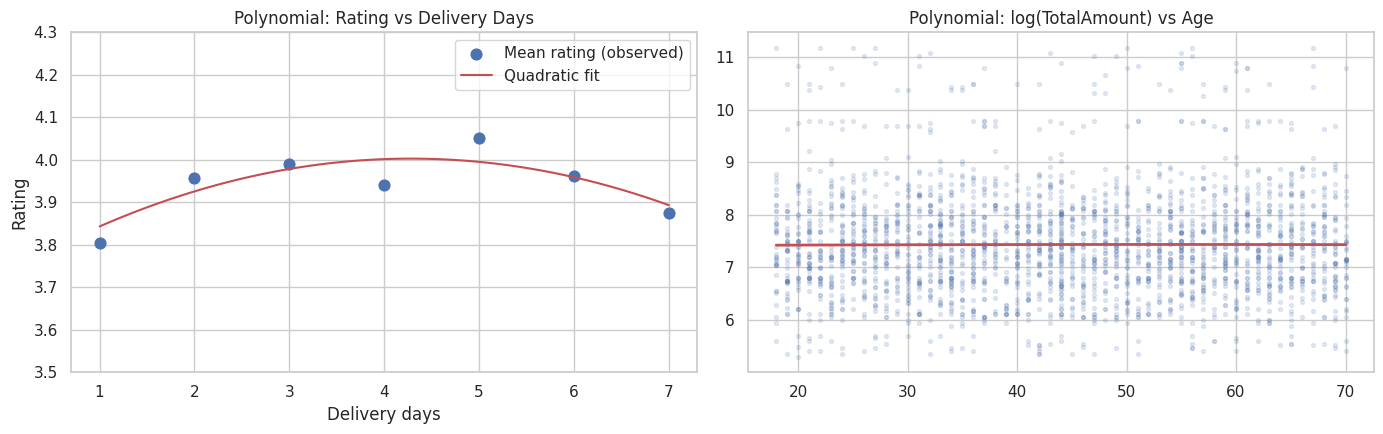

In [35]:
# (3) Polynomial regression (cross-sectional): Rating ~ DeliveryDays + DeliveryDays²  and  log(TotalAmount) ~ Age + Age²
rd = rated.dropna(subset=["DeliveryDays"])
p_lin = smf.ols("Rating ~ DeliveryDays", data=rd).fit()
p_quad = smf.ols("Rating ~ DeliveryDays + I(DeliveryDays**2)", data=rd).fit()
p_cub = smf.ols("Rating ~ DeliveryDays + I(DeliveryDays**2) + I(DeliveryDays**3)", data=rd).fit()
print(pd.DataFrame({"Degree": [1, 2, 3], "R²": [p_lin.rsquared, p_quad.rsquared, p_cub.rsquared],
                    "Adj R²": [p_lin.rsquared_adj, p_quad.rsquared_adj, p_cub.rsquared_adj],
                    "AIC": [p_lin.aic, p_quad.aic, p_cub.aic], "F p-value": [p_lin.f_pvalue, p_quad.f_pvalue, p_cub.f_pvalue]}))
print(p_quad.summary().tables[1])
p_age = smf.ols("np.log(TotalAmount) ~ CustomerAge + I(CustomerAge**2)", data=df).fit()
print(f"\nlog(TotalAmount) ~ Age + Age²: R² = {p_age.rsquared:.4f}, F p-value = {p_age.f_pvalue:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
grid = pd.DataFrame({"DeliveryDays": np.linspace(1, 7, 50)})
means = rd.groupby("DeliveryDays").Rating.mean()
ax[0].scatter(means.index, means.values, s=60, label="Mean rating (observed)")
ax[0].plot(grid.DeliveryDays, p_quad.predict(grid), "r-", label="Quadratic fit"); ax[0].set_ylim(3.5, 4.3)
ax[0].set_xlabel("Delivery days"); ax[0].set_ylabel("Rating"); ax[0].legend(); ax[0].set_title("Polynomial: Rating vs Delivery Days")
ga = pd.DataFrame({"CustomerAge": np.linspace(18, 70, 60)})
ax[1].scatter(df.CustomerAge, np.log(df.TotalAmount), alpha=.15, s=8)
ax[1].plot(ga.CustomerAge, p_age.predict(ga), "r-", lw=2); ax[1].set_title("Polynomial: log(TotalAmount) vs Age")
plt.tight_layout(); plt.show()

In [36]:
# (4) Regression with categorical variables (dummy coding; base levels shown in brackets)
m4 = smf.ols("np.log(TotalAmount) ~ C(Category, Treatment('Beauty')) + C(City, Treatment('Cairo')) + C(Gender) "
             "+ C(PaymentMethod) + Quantity + Discount", data=df).fit()
print(m4.summary().tables[0]); print(m4.summary().tables[1])

m4b = smf.ols("Rating ~ C(Category) + C(PaymentMethod) + C(Gender) + C(AgeGroup) + DeliveryDays + Discount", data=rd).fit()
print(f"\nRating model with categorical predictors: R² = {m4b.rsquared:.4f}, F = {m4b.fvalue:.3f}, p = {m4b.f_pvalue:.4f}")
display(sm.stats.anova_lm(m4b, typ=2))

                             OLS Regression Results                            
Dep. Variable:     np.log(TotalAmount)   R-squared:                       0.370
Model:                             OLS   Adj. R-squared:                  0.366
Method:                  Least Squares   F-statistic:                     91.25
Date:                 Sun, 27 Sep 2026   Prob (F-statistic):          3.87e-235
Time:                         12:21:00   Log-Likelihood:                -2920.4
No. Observations:                 2500   AIC:                             5875.
Df Residuals:                     2483   BIC:                             5974.
Df Model:                           16                                         
Covariance Type:             nonrobust                                         
                                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

,sum_sq,df,F,PR(>F)
C(Category),8.9598,4.0000,2.2823,0.0584
C(PaymentMethod),1.5755,4.0000,0.4013,0.8078
C(Gender),2.0685,1.0000,2.1076,0.1467
C(AgeGroup),1.9792,5.0000,0.4033,0.8468
DeliveryDays,0.8830,1.0000,0.8997,0.3430
Discount,0.0007,1.0000,0.0007,0.9782
Residual,"1,869.6810","1,905.0000",NaN,NaN


In [37]:
# (5) Logistic regression
# (5a) P(High rating 4-5)
lg1 = smf.logit("HighRating ~ DeliveryDays + Discount + CustomerAge + C(Category) + C(Gender) + C(PaymentMethod)", data=rd).fit(disp=0)
print(lg1.summary().tables[1])
print(f"McFadden pseudo-R² = {lg1.prsquared:.4f} | LLR p-value = {lg1.llr_pvalue:.4f}")
or1 = pd.DataFrame({"Odds Ratio": np.exp(lg1.params), "p-value": lg1.pvalues}); display(or1)

# (5b) P(Order cancelled)
lg2 = smf.logit("IsCancelled ~ Discount + CustomerAge + np.log(TotalAmount) + C(Category) + C(PaymentMethod) + C(Gender)", data=df).fit(disp=0)
print(lg2.summary().tables[1])
print(f"McFadden pseudo-R² = {lg2.prsquared:.4f} | LLR p-value = {lg2.llr_pvalue:.4f}")

from sklearn.metrics import roc_auc_score, confusion_matrix
for name, mdl, y in [("High rating", lg1, rd.HighRating), ("Cancellation", lg2, df.IsCancelled)]:
    prob = mdl.predict(); thr = y.mean()
    print(f"{name}: AUC = {roc_auc_score(y, prob):.3f} | confusion matrix @ threshold {thr:.2f}:\n{confusion_matrix(y, prob > thr)}")

                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          0.8060      0.266      3.033      0.002       0.285       1.327
C(Category)[T.Electronics]         0.3071      0.167      1.845      0.065      -0.019       0.633
C(Category)[T.Fashion]             0.1575      0.165      0.956      0.339      -0.165       0.480
C(Category)[T.Home]                0.3892      0.170      2.292      0.022       0.056       0.722
C(Category)[T.Sports]             -0.0031      0.166     -0.019      0.985      -0.328       0.322
C(Gender)[T.Male]                  0.1107      0.105      1.053      0.292      -0.095       0.317
C(PaymentMethod)[T.Cash]          -0.2108      0.166     -1.267      0.205      -0.537       0.115
C(PaymentMethod)[T.Mastercard]    -0.1978      0.167     -1.183      0.237      -0.526       0.130
C(PaymentM

,Odds Ratio,p-value
Intercept,2.2388,0.0024
C(Category)[T.Electronics],1.3595,0.0651
C(Category)[T.Fashion],1.1706,0.3392
C(Category)[T.Home],1.4758,0.0219
C(Category)[T.Sports],0.9969,0.9850
C(Gender)[T.Male],1.1171,0.2923
C(PaymentMethod)[T.Cash],0.8099,0.2053
C(PaymentMethod)[T.Mastercard],0.8205,0.2369
C(PaymentMethod)[T.Visa],0.7705,0.1221
C(PaymentMethod)[T.Wallet],0.8902,0.4882


                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -1.4061      0.607     -2.315      0.021      -2.597      -0.216
C(Category)[T.Electronics]         0.2033      0.231      0.881      0.378      -0.249       0.655
C(Category)[T.Fashion]             0.0144      0.228      0.063      0.950      -0.433       0.462
C(Category)[T.Home]                0.0314      0.232      0.135      0.892      -0.423       0.486
C(Category)[T.Sports]              0.3737      0.221      1.692      0.091      -0.059       0.806
C(PaymentMethod)[T.Cash]          -0.0976      0.226     -0.433      0.665      -0.540       0.345
C(PaymentMethod)[T.Mastercard]     0.0743      0.216      0.343      0.731      -0.350       0.499
C(PaymentMethod)[T.Visa]           0.0423      0.220      0.192      0.847      -0.389       0.473
C(PaymentM

In [38]:
reg_summary = pd.DataFrame([
    ["Multiple linear (log)", "log(TotalAmount)", "Qty, log(Price), Discount, Age", m1.rsquared, m1.f_pvalue],
    ["Multiple linear (levels)", "TotalAmount", "Qty, Price, Discount, Age", m1b.rsquared, m1b.f_pvalue],
    ["Time-series (trend)", "Daily Revenue", "t", m2r.rsquared, m2r.f_pvalue],
    ["Time-series (trend + DOW)", "Daily Orders", "t, Day-of-week", m2.rsquared, m2.f_pvalue],
    ["Polynomial (deg 2)", "Rating", "DeliveryDays, DeliveryDays²", p_quad.rsquared, p_quad.f_pvalue],
    ["Polynomial (deg 2)", "log(TotalAmount)", "Age, Age²", p_age.rsquared, p_age.f_pvalue],
    ["Categorical regression", "log(TotalAmount)", "Category, City, Gender, Payment, Qty, Discount", m4.rsquared, m4.f_pvalue],
    ["Categorical regression", "Rating", "Category, Payment, Gender, AgeGroup, Delivery, Discount", m4b.rsquared, m4b.f_pvalue],
    ["Logistic", "HighRating (0/1)", "Delivery, Discount, Age, Category, Gender, Payment", lg1.prsquared, lg1.llr_pvalue],
    ["Logistic", "IsCancelled (0/1)", "Discount, Age, log(Amount), Category, Payment, Gender", lg2.prsquared, lg2.llr_pvalue],
], columns=["Model", "Dependent", "Predictors", "R² / Pseudo-R²", "Model p-value"])
reg_summary

,Model,Dependent,Predictors,R² / Pseudo-R²,Model p-value
0,Multiple linear (log),log(TotalAmount),"Qty, log(Price), Discount, Age",0.9887,0.0000
1,Multiple linear (levels),TotalAmount,"Qty, Price, Discount, Age",0.7838,0.0000
2,Time-series (trend),Daily Revenue,t,0.0034,0.4375
3,Time-series (trend + DOW),Daily Orders,"t, Day-of-week",0.0497,0.2599
4,Polynomial (deg 2),Rating,"DeliveryDays, DeliveryDays²",0.0021,0.1318
5,Polynomial (deg 2),log(TotalAmount),"Age, Age²",0.0000,0.9825
6,Categorical regression,log(TotalAmount),"Category, City, Gender, Payment, Qty, Discount",0.3703,0.0000
7,Categorical regression,Rating,"Category, Payment, Gender, AgeGroup, Delivery,...",0.0081,0.4815
8,Logistic,HighRating (0/1),"Delivery, Discount, Age, Category, Gender, Pay...",0.0065,0.2892
9,Logistic,IsCancelled (0/1),"Discount, Age, log(Amount), Category, Payment,...",0.0102,0.1821


## 5. Observations | Findings
*(Sample of 2,500 orders, seed 112348; α = 0.05)*

**Data quality**
1. The raw file (10,020 × 16) had 20 duplicate records, 10 spellings of Gender, 30 of City, 20 of Category, 6 different date formats, discounts stored both as `0.1` and `10%`, 80 non-positive quantities, 40 impossible prices (0, −500, 75,000–150,000), 25 impossible ages (−3, 5, 150) and 15 ratings outside 1–5. After cleaning, **10,000 valid orders** remain; only `DeliveryDate`/`Rating` are missing, and only for undelivered orders (structural).

**Customer & sales profile**
2. Customers are aged **18–70 (mean 43.9, median 44)** with an almost flat, platykurtic distribution (kurtosis −1.19); the largest age group is 36–45 (19.7%), the smallest 66–80 (8.0%).
3. Gender is balanced (Male 50.3%, Female 49.7%). **Cairo** is the largest market (38.3% of orders, 36.6% of revenue); **Aswan** is the smallest (5.6% of orders). Cairo + Giza + Alexandria = **79% of revenue**.
4. **Category shares are not uniform** (χ² GOF p = 0.033): Electronics is ordered most (21.6%) and Beauty least (17.8%). Payment methods, by contrast, are used almost equally (19.5%–20.4%; χ² GOF p = 0.97), with Wallet slightly ahead.
5. **79.0% delivered, 11.4% pending, 9.6% cancelled** (95% CI for cancellation: 8.5%–10.9%). Cancelled + pending orders hold ≈ **20.6% of booked revenue**.

**Order value (revenue drivers)**
6. `TotalAmount` is extremely right-skewed (skew 6.01, kurtosis 40.4): mean **EGP 3,366** vs median **EGP 1,530**. All four normality tests reject normality even after log transformation, so non-parametric tests were run alongside parametric ones.
7. **Electronics = 21.6% of orders but 54.4% of revenue**; **Laptops alone = 43.6%** of revenue from 4.4% of orders. Mean order value differs strongly by category (ANOVA F = 88.7, p < 0.001; Kruskal-Wallis p < 0.001), and so do variances (Levene & Bartlett p < 0.001). Electronics' mean order (EGP 8,460; CI 7,185–9,735) is ~5.9× Beauty (EGP 1,437).
8. Order value does **not** differ by gender (Welch t p = 0.71; Mann-Whitney p = 0.19; two-way ANOVA interaction p = 0.62) or by city (ANOVA p = 0.19), and is unrelated to age (r = −0.003, p = 0.86; quadratic age model R² ≈ 0).
9. The log-linear regression explains **98.9%** of the variation in order value: price elasticity ≈ **1.0**, each extra unit raises order value by ≈ **60%** on average, and each +1 pp discount reduces it by ≈ **1.1%**. The categorical regression confirms category as the key driver (an Electronics order is ≈ **2.6×** a Beauty order after controls), with City, Gender and Payment Method all insignificant.
10. **Discounts cost 6.7% of gross sales** (paired t and Wilcoxon p < 0.001) but do **not** raise units per order (1.95 units at 0% vs 1.97 at 20%; Spearman p = 0.26) or ratings (r = −0.002, p = 0.92). Cancellations are somewhat lower at 15–20% discounts (7.1–7.7% vs 10.6% at 0%) and the discount coefficient in the cancellation logit is significant (p = 0.043), but the discount × cancellation χ² test is not (p = 0.36) and the overall model is not significant — a weak signal, not a proven effect.

**Customer satisfaction**
11. Mean rating **3.96** (CI 3.92–4.01); **74.5% rate 4–5**, 9.3% rate 1–2. The mean is not significantly different from a 4.0 target (t-test p = 0.10; Wilcoxon p = 0.15).
12. Rating is **not** explained by delivery days (r = 0.02, p = 0.38; ANOVA p = 0.31; polynomial R² = 0.2%), category (ANOVA p = 0.09, Kruskal p = 0.16, χ² p = 0.32), payment method (Kruskal p = 0.59) or gender (p = 0.18). The logistic model for a high rating is not significant overall (LLR p = 0.29, AUC 0.55).

**Cancellations & trend**
13. The cancellation rate (9.6%) is statistically equal to a 10% benchmark (z p = 0.54) and independent of category (χ² p = 0.65), payment method (χ² p = 0.26) and gender (z p = 0.07). The cancellation logit is not significant overall (LLR p = 0.18, AUC 0.58) — cancellations are **spread fairly evenly across segments**.
14. Monthly revenue is **stable** at EGP 1.29–1.56 million per month (peak in January); the daily time-series regression shows no significant trend (slope −35 EGP/day, p = 0.44) and no day-of-week effect (p = 0.26). The Friedman test confirms that categories differ consistently in monthly revenue (p < 0.001) but not in monthly order counts (p = 0.24).

## 6. Managerial Insights | Recommendations

1. **Revenue depends on one category and one product.** Electronics (54.4%) and especially Laptops (43.6%) carry the business. *Recommendation:* guarantee Laptop stock, offer extended warranty / EMI plans and priority delivery, and track Electronics KPIs weekly — a small change in Laptop sales moves total revenue more than any other lever.
2. **Blanket discounts give away margin with little return.** 6.7% of gross sales is discounted away, yet discounted orders are not larger and not better rated; the possible reduction in cancellations at high discounts is weak and unconfirmed. *Recommendation:* replace across-the-board discounts with targeted, measurable offers (bundles, cart-value thresholds, first-order coupons) and A/B test whether discounts genuinely reduce cancellations before scaling them.
3. **One-fifth of booked value is not realised.** Pending (11.4%) and cancelled (9.6%) orders hold ≈ 20.6% of booked revenue, and cancellations occur at similar rates in every segment — the cause is *process-wide*, not customer-specific. *Recommendation:* add a mandatory cancellation-reason field, payment-retry and reminder messages for pending orders, and review order-confirmation and stock-check steps.
4. **Satisfaction drivers are outside the current data.** Ratings are high (74.5% ≥ 4, mean ≈ 4.0) but no recorded variable explains the 9.3% low ratings. *Recommendation:* collect review text, return reasons, product-quality and courier data so low ratings can be diagnosed; set a target of mean rating ≥ 4.0.
5. **Growth headroom in smaller cities.** Mansoura, Tanta and Aswan together contribute only 21% of revenue while spending per order is the same as in Cairo. *Recommendation:* local digital campaigns and delivery partnerships to grow order volume there.
6. **Beauty is the smallest category by orders and revenue.** It has the lowest order share (17.8%) and the lowest average order value (EGP 1,437). *Recommendation:* use Beauty for bundles and cross-selling with high-traffic categories to lift basket size.
7. **Use the dashboard for monitoring.** The Streamlit dashboard lets managers filter by date, city, category, gender, payment, status, age and discount and re-run every test and model live on the selection.

## 7. Streamlit Dashboard

The next cell writes `app.py`, the full dashboard. It uses **exactly the same cleaning function and seed**, so its numbers match this notebook.

**Dashboard features:** sidebar filters (date, city, category, gender, payment, status, age, discount) · KPI cards · 7 tabs — *Overview · Data & Cleaning · Descriptive · Visual Explorer (scatter, line, box, violin, heat map, pair, bar, histogram, pie) · Inferential Tests (CI, normality, t, ANOVA, F/Levene/Bartlett, z, correlation t, χ² GOF & independence, Mann-Whitney, Wilcoxon, Kruskal-Wallis, Friedman) · Regression (linear, time-series, polynomial, categorical, logistic) · Insights* · CSV download.

**Deploy for a live link (Streamlit Community Cloud, free):**
1. In the GitHub repo that holds `shopease_raw_orders.csv`, upload `app.py` and `requirements.txt` (both are written by the cells below).
2. Go to **share.streamlit.io** → sign in with GitHub → **Create app** → choose the repo, branch `main`, main file `app.py` → **Deploy**.
3. Copy the app URL into the **Live Dashboard Link** in Section 1.

In [39]:
%%writefile app.py
# =====================================================================
#  ShopEase Dynamic Analytical Dashboard  |  FBDA Project
#  Group ID: 011_023_048   |   Seed: 112348
#  Run locally:  streamlit run app.py
# =====================================================================
import io, os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

warnings.filterwarnings("ignore")
st.set_page_config(page_title="ShopEase Analytics | Group 011_023_048", page_icon="🛒", layout="wide")
sns.set_theme(style="whitegrid", palette="deep")

GROUP_ID = "011_023_048"
SEED = int("".join(str(int(p)) for p in GROUP_ID.split("_")))       # 112348
SAMPLE_SIZE = 2500
ALPHA = 0.05
# >>> Replace with the raw GitHub link of the CSV <<<
DATA_URL = "https://raw.githubusercontent.com/<your-username>/<your-repo>/main/shopease_raw_orders.csv"
LOCAL_FILE = "shopease_raw_orders.csv"
VALID_DISCOUNTS = np.array([0.0, 0.05, 0.10, 0.15, 0.20])


# =====================================================================
#  DATA CLEANING (identical to the notebook)
# =====================================================================


def parse_date(x):
    """Parse the mixed OrderDate formats found in the raw file."""
    if pd.isna(x):
        return pd.NaT
    s = str(x).strip()
    if s.lower() in ("not available", "na", "n/a", ""):
        return pd.NaT
    for fmt in ("%Y-%m-%d %H:%M:%S", "%Y-%m-%d", "%d/%m/%Y", "%d-%m-%Y", "%b %d %Y"):
        try:
            return pd.to_datetime(s, format=fmt)
        except ValueError:
            continue
    return pd.NaT


def clean_data(df_raw):
    """Clean the raw ShopEase orders and return (clean_df, cleaning_log)."""
    df = df_raw.copy()
    log = []
    n0 = len(df)

    # 1. Standardise text columns (spaces, case, spelling)
    for c in ["Gender", "City", "Category", "Product", "PaymentMethod", "OrderStatus", "CustomerID"]:
        df[c] = df[c].str.strip()
    df["Gender"] = df["Gender"].str.lower().map({"male": "Male", "m": "Male", "female": "Female", "f": "Female"})
    df["City"] = df["City"].str.title()
    df["Category"] = df["Category"].str.title()
    df["Product"] = df["Product"].str.title().str.replace("T-Shirt", "T-Shirt", case=False)
    df["PaymentMethod"] = df["PaymentMethod"].str.title().replace({"Visa": "Visa"})
    df["OrderStatus"] = df["OrderStatus"].str.title().replace({"Canceled": "Cancelled"})
    log.append("Trimmed spaces and standardised case/spelling in Gender, City, Category, Product, PaymentMethod, OrderStatus")

    # 2. Duplicates: exact duplicates, then duplicate OrderIDs (keep most complete record)
    d1 = df.duplicated().sum()
    df = df.drop_duplicates()
    df["_nnull"] = df.isna().sum(axis=1)
    df = df.sort_values(["OrderID", "_nnull"])
    d2 = df["OrderID"].duplicated().sum()
    df = df.drop_duplicates("OrderID", keep="first").drop(columns="_nnull")
    log.append(f"Removed {d1} exact duplicate rows and {d2} further duplicate OrderIDs")

    # 3. Dates
    df["OrderDate"] = df["OrderDate"].apply(parse_date)
    df["DeliveryDate"] = pd.to_datetime(df["DeliveryDate"], errors="coerce")
    log.append(f"Parsed 6 different OrderDate formats; {df['OrderDate'].isna().sum()} 'not available' dates left missing")

    # 4. Discount: '10%' -> 0.10
    disc = df["Discount"].str.strip().str.rstrip("%")
    disc = pd.to_numeric(disc, errors="coerce").astype(float)
    df["Discount"] = np.where(disc > 1, disc / 100, disc)

    # 5. UnitPrice: each product has one list price; replace 0 / negative / extreme values
    std_price = df[df["UnitPrice"] > 0].groupby("Product")["UnitPrice"].agg(lambda s: s.mode().iloc[0])
    bad_price = df["UnitPrice"] != df["Product"].map(std_price)
    bad_price &= df["Product"].notna()
    df.loc[bad_price, "UnitPrice"] = df.loc[bad_price, "Product"].map(std_price)
    log.append(f"Corrected {int(bad_price.sum())} invalid UnitPrice values (0, -500, 75k-150k) to the product's list price")

    # 6. Missing Product: infer from Category + UnitPrice where unique
    lookup = df.dropna(subset=["Product"]).groupby(["Category", "UnitPrice"])["Product"].agg(
        lambda s: s.mode().iloc[0] if s.nunique() == 1 else np.nan)
    miss_p = df["Product"].isna()
    df.loc[miss_p, "Product"] = [lookup.get((c, p), np.nan) for c, p in
                                 zip(df.loc[miss_p, "Category"], df.loc[miss_p, "UnitPrice"])]
    df["Product"] = df["Product"].fillna("Unknown")
    log.append(f"Inferred {int(miss_p.sum() - (df['Product'] == 'Unknown').sum())} missing Product names from Category + price")

    # 7. Quantity: negatives are sign errors; zeros are recovered from TotalAmount
    neg = (df["Quantity"] < 0).sum()
    df["Quantity"] = df["Quantity"].abs()
    zero = df["Quantity"] == 0
    d_tmp = df["Discount"].fillna(0)
    df.loc[zero, "Quantity"] = (df.loc[zero, "TotalAmount"] /
                                (df.loc[zero, "UnitPrice"] * (1 - d_tmp[zero]))).round().clip(1, 4)
    df["Quantity"] = df["Quantity"].astype(int)
    log.append(f"Fixed {neg} negative quantities (sign error) and {int(zero.sum())} zero quantities (recovered from TotalAmount)")

    # 8. Missing discount: back-solve from TotalAmount, snap to nearest valid level
    miss_d = df["Discount"].isna()
    implied = 1 - df.loc[miss_d, "TotalAmount"] / (df.loc[miss_d, "Quantity"] * df.loc[miss_d, "UnitPrice"])
    df.loc[miss_d, "Discount"] = [VALID_DISCOUNTS[np.abs(VALID_DISCOUNTS - v).argmin()] for v in implied]
    log.append(f"Imputed {int(miss_d.sum())} missing discounts from TotalAmount / (Quantity x UnitPrice)")

    # 9. TotalAmount: recompute so it is internally consistent
    recomputed = (df["Quantity"] * df["UnitPrice"] * (1 - df["Discount"])).round(2)
    fixed_ta = (~np.isclose(recomputed, df["TotalAmount"])).sum()
    df["TotalAmount"] = recomputed
    log.append(f"Recomputed TotalAmount = Quantity x UnitPrice x (1 - Discount); {fixed_ta} inconsistent values corrected")

    # 10. Age: impossible values (<18 or >80) -> missing -> median
    bad_age = ((df["CustomerAge"] < 18) | (df["CustomerAge"] > 80)).sum()
    df.loc[(df["CustomerAge"] < 18) | (df["CustomerAge"] > 80), "CustomerAge"] = np.nan
    miss_age = df["CustomerAge"].isna().sum()
    df["CustomerAge"] = df["CustomerAge"].fillna(df["CustomerAge"].median()).astype(int)
    log.append(f"Set {bad_age} impossible ages (-3, 5, 150) to missing; imputed {miss_age} ages with the median")

    # 11. Rating: valid 1-5 only; missing is legitimate for non-delivered orders
    bad_r = (~df["Rating"].between(1, 5) & df["Rating"].notna()).sum()
    df.loc[~df["Rating"].between(1, 5), "Rating"] = np.nan
    log.append(f"Set {bad_r} out-of-range ratings (-1, 0, 6) to missing; ratings kept only where given (mostly delivered orders)")

    # 12. Remaining categorical gaps
    df["CustomerID"] = df["CustomerID"].fillna("Unknown")
    pm_mode = df["PaymentMethod"].mode().iloc[0]
    df["PaymentMethod"] = df["PaymentMethod"].fillna(pm_mode)
    log.append(f"Filled missing CustomerID with 'Unknown' and missing PaymentMethod with the mode ({pm_mode})")

    # 13. Derived features
    df["DeliveryDays"] = (df["DeliveryDate"] - df["OrderDate"]).dt.days
    df.loc[df["DeliveryDays"] < 0, "DeliveryDays"] = np.nan
    df["OrderMonth"] = df["OrderDate"].dt.strftime("%Y-%m")
    df["DiscountPct"] = (df["Discount"] * 100).round().astype(int)
    df["AgeGroup"] = pd.cut(df["CustomerAge"], [17, 25, 35, 45, 55, 65, 80],
                            labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66-80"]).astype(object)
    df["IsCancelled"] = (df["OrderStatus"] == "Cancelled").astype(int)
    df["HighRating"] = np.where(df["Rating"].isna(), np.nan, (df["Rating"] >= 4).astype(float))
    log.append("Added DeliveryDays, OrderMonth, DiscountPct, AgeGroup, IsCancelled, HighRating")

    df = df.reset_index(drop=True)
    log.append(f"Rows: {n0} raw -> {len(df)} clean")
    return df, log

# =====================================================================
#  DATA LOADING (cached)
# =====================================================================
@st.cache_data(show_spinner="Loading and cleaning data...")
def load_all(url):
    if os.path.exists(LOCAL_FILE):
        raw = pd.read_csv(LOCAL_FILE)
    else:
        raw = pd.read_csv(url)
    clean, log = clean_data(raw)
    random.seed(SEED); np.random.seed(SEED)
    sample = clean.sample(n=SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
    return raw, clean, sample, log


def show(fig):
    st.pyplot(fig, clear_figure=True)
    plt.close("all")


def decision(p):
    return "✅ Reject H₀ (significant)" if p < ALPHA else "❌ Fail to reject H₀ (not significant)"


def result_box(name, stat_name, stat, p, h0, extra=""):
    c1, c2, c3 = st.columns(3)
    c1.metric(stat_name, f"{stat:,.4f}")
    c2.metric("p-value", f"{p:.4g}")
    c3.metric("Decision (α = 0.05)", "Reject H₀" if p < ALPHA else "Fail to reject H₀")
    st.caption(f"**{name}** — H₀: {h0}. {decision(p)}. {extra}")


try:
    raw, clean, sample, cleaning_log = load_all(DATA_URL)
except Exception as e:
    st.error(f"Could not load data. Put `{LOCAL_FILE}` next to app.py or set DATA_URL. Error: {e}")
    st.stop()

# =====================================================================
#  SIDEBAR: dataset + filters
# =====================================================================
st.sidebar.title("🛒 ShopEase Analytics")
st.sidebar.caption(f"Group **{GROUP_ID}** · seed **{SEED}**")
base_choice = st.sidebar.radio("Dataset", [f"Random sample (n = {SAMPLE_SIZE:,})", f"Full clean data (n = {len(clean):,})"])
base = sample if base_choice.startswith("Random") else clean

st.sidebar.markdown("### Filters")
dmin, dmax = base.OrderDate.min().date(), base.OrderDate.max().date()
date_range = st.sidebar.date_input("Order date range", (dmin, dmax), min_value=dmin, max_value=dmax)
f_city = st.sidebar.multiselect("City", sorted(base.City.unique()), default=sorted(base.City.unique()))
f_cat = st.sidebar.multiselect("Category", sorted(base.Category.unique()), default=sorted(base.Category.unique()))
f_gender = st.sidebar.multiselect("Gender", sorted(base.Gender.unique()), default=sorted(base.Gender.unique()))
f_pay = st.sidebar.multiselect("Payment method", sorted(base.PaymentMethod.unique()), default=sorted(base.PaymentMethod.unique()))
f_status = st.sidebar.multiselect("Order status", sorted(base.OrderStatus.unique()), default=sorted(base.OrderStatus.unique()))
f_age = st.sidebar.slider("Customer age", int(base.CustomerAge.min()), int(base.CustomerAge.max()),
                          (int(base.CustomerAge.min()), int(base.CustomerAge.max())))
f_disc = st.sidebar.multiselect("Discount %", sorted(base.DiscountPct.unique()), default=sorted(base.DiscountPct.unique()))

mask = (base.City.isin(f_city) & base.Category.isin(f_cat) & base.Gender.isin(f_gender) &
        base.PaymentMethod.isin(f_pay) & base.OrderStatus.isin(f_status) &
        base.CustomerAge.between(*f_age) & base.DiscountPct.isin(f_disc))
if isinstance(date_range, (tuple, list)) and len(date_range) == 2:
    mask &= (base.OrderDate.dt.date.between(date_range[0], date_range[1]) | base.OrderDate.isna())
df = base[mask].copy()
rated = df.dropna(subset=["Rating"])
st.sidebar.success(f"{len(df):,} orders match the filters")
st.sidebar.download_button("⬇️ Download filtered data (CSV)", df.to_csv(index=False).encode(), "shopease_filtered.csv", "text/csv")

if len(df) < 30:
    st.warning("Fewer than 30 orders match the filters — widen the filters to run the analysis.")
    st.stop()

NUM_COLS = ["CustomerAge", "Quantity", "UnitPrice", "Discount", "TotalAmount", "Rating", "DeliveryDays"]
CAT_COLS = ["Gender", "City", "Category", "Product", "PaymentMethod", "OrderStatus", "AgeGroup", "DiscountPct"]

# =====================================================================
#  HEADER + KPIs
# =====================================================================
st.title("ShopEase E-Commerce — Dynamic Analytical Dashboard")
st.caption("Foundations of Big Data Analytics with Python · Orders Jan–Jun 2026 · all figures react to the sidebar filters")

k = st.columns(6)
k[0].metric("Orders", f"{len(df):,}")
k[1].metric("Revenue (EGP)", f"{df.TotalAmount.sum():,.0f}")
k[2].metric("Avg order value", f"{df.TotalAmount.mean():,.0f}")
k[3].metric("Avg rating", f"{rated.Rating.mean():.2f} / 5" if len(rated) else "–")
k[4].metric("Cancellation rate", f"{df.IsCancelled.mean() * 100:.1f}%")
k[5].metric("Avg delivery days", f"{df.DeliveryDays.mean():.2f}")

tabs = st.tabs(["📊 Overview", "🗂️ Data & Cleaning", "📐 Descriptive", "🎨 Visual Explorer",
                "🧪 Inferential Tests", "📈 Regression", "💡 Insights"])

# =====================================================================
#  TAB 1: OVERVIEW
# =====================================================================
with tabs[0]:
    c1, c2 = st.columns(2)
    with c1:
        st.subheader("Monthly revenue & orders")
        mon = df.dropna(subset=["OrderMonth"]).groupby("OrderMonth").agg(Revenue=("TotalAmount", "sum"), Orders=("OrderID", "count"))
        fig, ax = plt.subplots(figsize=(7, 4)); ax2 = ax.twinx()
        ax.bar(mon.index, mon.Revenue / 1e3, color="steelblue", alpha=.7); ax.set_ylabel("Revenue (EGP '000)")
        ax2.plot(mon.index, mon.Orders, "o-", color="darkorange", lw=2); ax2.set_ylabel("Orders"); ax2.grid(False)
        show(fig)
    with c2:
        st.subheader("Revenue share by category")
        rc = df.groupby("Category").TotalAmount.sum().sort_values()
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.barh(rc.index, rc / rc.sum() * 100, color=sns.color_palette("viridis", len(rc)))
        for i, v in enumerate(rc / rc.sum() * 100): ax.text(v + .5, i, f"{v:.1f}%", va="center")
        ax.set_xlabel("% of revenue"); show(fig)
    c3, c4, c5 = st.columns(3)
    with c3:
        st.subheader("Revenue by city")
        fig, ax = plt.subplots(figsize=(5, 4))
        (df.groupby("City").TotalAmount.sum().sort_values(ascending=False) / 1e3).plot.bar(ax=ax, color="teal")
        ax.set_ylabel("EGP '000"); ax.set_xlabel(""); show(fig)
    with c4:
        st.subheader("Order status")
        fig, ax = plt.subplots(figsize=(5, 4))
        df.OrderStatus.value_counts().plot.pie(autopct="%1.1f%%", ax=ax, startangle=90, colors=["#4c72b0", "#dd8452", "#c44e52"])
        ax.set_ylabel(""); show(fig)
    with c5:
        st.subheader("Top 10 products (revenue)")
        fig, ax = plt.subplots(figsize=(5, 4))
        (df.groupby("Product").TotalAmount.sum().nlargest(10).sort_values() / 1e3).plot.barh(ax=ax, color="slateblue")
        ax.set_xlabel("EGP '000"); ax.set_ylabel(""); show(fig)

# =====================================================================
#  TAB 2: DATA & CLEANING
# =====================================================================
with tabs[1]:
    st.subheader("Description of data")
    d1, d2, d3, d4 = st.columns(4)
    d1.metric("Raw records", f"{len(raw):,}"); d2.metric("Clean records", f"{len(clean):,}")
    d3.metric("Variables (raw → clean)", f"{raw.shape[1]} → {clean.shape[1]}"); d4.metric("Sample", f"{SAMPLE_SIZE:,} (seed {SEED})")
    st.markdown("**Data type:** Cross-sectional (orders) with timestamps · **Span:** Static, Jan–Jun 2026 · **Source:** course dataset (`shopease_raw_orders.csv`)")
    st.subheader("Cleaning steps applied")
    for i, s in enumerate(cleaning_log, 1):
        st.markdown(f"{i}. {s}")
    c1, c2 = st.columns(2)
    with c1:
        st.markdown("**Missing values — raw**")
        st.dataframe(raw.isna().sum().rename("Missing").to_frame().query("Missing > 0"))
    with c2:
        st.markdown("**Missing values — clean** (structural: not delivered / not rated)")
        st.dataframe(clean.isna().sum().rename("Missing").to_frame().query("Missing > 0"))
    view = st.radio("Preview", ["Filtered data", "Raw data"], horizontal=True)
    st.dataframe((df if view == "Filtered data" else raw).head(200), width="stretch")

# =====================================================================
#  TAB 3: DESCRIPTIVE
# =====================================================================
with tabs[2]:
    st.subheader("Non-categorical variables")
    rows = {}
    for c in NUM_COLS:
        x = df[c].dropna()
        if len(x) < 3: continue
        rows[c] = {"Count": x.count(), "Min": x.min(), "P25": x.quantile(.25), "Median": x.median(), "P75": x.quantile(.75),
                   "Max": x.max(), "Mean": x.mean(), "Mode": x.mode().iloc[0], "Range": x.max() - x.min(),
                   "Std Dev": x.std(), "Skewness": stats.skew(x), "Kurtosis": stats.kurtosis(x)}
    st.dataframe(pd.DataFrame(rows).T.style.format("{:,.3f}"), width="stretch")
    pct = st.slider("Custom percentile", 1, 99, 90)
    st.write({c: round(df[c].dropna().quantile(pct / 100), 3) for c in NUM_COLS})

    st.subheader("Correlation")
    method = st.radio("Method", ["pearson", "spearman"], horizontal=True)
    cols = st.multiselect("Variables", NUM_COLS, default=NUM_COLS)
    if len(cols) >= 2:
        fig, ax = plt.subplots(figsize=(8, 5.5))
        sns.heatmap(df[cols].corr(method=method), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
        ax.set_title(f"{method.title()} correlation"); show(fig)

    st.subheader("Categorical variables")
    cv = st.selectbox("Variable", CAT_COLS + ["Rating"], index=2)
    vc = (rated if cv == "Rating" else df)[cv].value_counts()
    freq = pd.DataFrame({"Frequency": vc, "Relative frequency": vc / vc.sum(), "Percent": vc / vc.sum() * 100})
    c1, c2 = st.columns([1, 1.3])
    c1.dataframe(freq.style.format({"Relative frequency": "{:.4f}", "Percent": "{:.2f}%"}))
    c1.info(f"Highest: **{vc.idxmax()}** ({vc.max()}, {vc.max() / vc.sum() * 100:.1f}%) · "
            f"Lowest: **{vc.idxmin()}** ({vc.min()}, {vc.min() / vc.sum() * 100:.1f}%)")
    with c2:
        fig, ax = plt.subplots(figsize=(7, 4)); vc.plot.bar(ax=ax, color="steelblue"); ax.set_title(f"Frequency of {cv}"); show(fig)

# =====================================================================
#  TAB 4: VISUAL EXPLORER
# =====================================================================
with tabs[3]:
    chart = st.selectbox("Chart type", ["Scatter plot", "Line plot (monthly)", "Box-whisker plot", "Violin plot",
                                        "Heat map (pivot)", "Pair plot", "Bar plot", "Histogram", "Pie chart"])
    cats = ["Category", "City", "Gender", "PaymentMethod", "OrderStatus", "AgeGroup", "DiscountPct"]
    fig = None
    if chart == "Scatter plot":
        c1, c2, c3, c4 = st.columns(4)
        x = c1.selectbox("X", NUM_COLS, index=0); y = c2.selectbox("Y", NUM_COLS, index=4)
        hue = c3.selectbox("Colour by", ["None"] + cats); logy = c4.checkbox("Log Y", value=(y == "TotalAmount"))
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.scatterplot(data=df, x=x, y=y, hue=None if hue == "None" else hue, alpha=.5, ax=ax)
        if logy: ax.set_yscale("log")
        r, p = stats.pearsonr(df[[x, y]].dropna()[x], df[[x, y]].dropna()[y]); ax.set_title(f"{y} vs {x}  (Pearson r = {r:.3f}, p = {p:.3g})")
    elif chart == "Line plot (monthly)":
        c1, c2, c3 = st.columns(3)
        metric = c1.selectbox("Metric", ["TotalAmount", "OrderID", "Rating", "IsCancelled", "DeliveryDays"])
        agg = c2.selectbox("Aggregation", ["sum", "mean", "count"]); split = c3.selectbox("Split by", ["None"] + cats)
        d = df.dropna(subset=["OrderMonth"])
        fig, ax = plt.subplots(figsize=(10, 5))
        if split == "None":
            d.groupby("OrderMonth")[metric].agg(agg).plot(marker="o", ax=ax)
        else:
            d.pivot_table(index="OrderMonth", columns=split, values=metric, aggfunc=agg).plot(marker="o", ax=ax)
        ax.set_title(f"{agg}({metric}) by month")
    elif chart in ("Box-whisker plot", "Violin plot"):
        c1, c2, c3 = st.columns(3)
        y = c1.selectbox("Numeric variable", NUM_COLS, index=4); x = c2.selectbox("Group by", cats)
        logy = c3.checkbox("Log Y", value=(y == "TotalAmount"))
        fig, ax = plt.subplots(figsize=(10, 5))
        (sns.boxplot if chart.startswith("Box") else sns.violinplot)(data=df, x=x, y=y, ax=ax)
        if logy: ax.set_yscale("log")
        ax.set_title(f"{y} by {x}")
    elif chart == "Heat map (pivot)":
        c1, c2, c3, c4 = st.columns(4)
        r_ = c1.selectbox("Rows", cats, index=0); c_ = c2.selectbox("Columns", cats, index=1)
        v_ = c3.selectbox("Value", ["TotalAmount", "OrderID", "Rating", "IsCancelled", "Quantity"]); a_ = c4.selectbox("Agg", ["sum", "mean", "count"], index=1)
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.heatmap(df.pivot_table(index=r_, columns=c_, values=v_, aggfunc=a_), annot=True, fmt=".2f" if a_ == "mean" else ".0f", cmap="YlGnBu", ax=ax)
        ax.set_title(f"{a_}({v_}): {r_} × {c_}")
    elif chart == "Pair plot":
        cols = st.multiselect("Variables", NUM_COLS, default=["CustomerAge", "Quantity", "TotalAmount", "Rating"])
        hue = st.selectbox("Colour by", ["None"] + cats)
        if len(cols) >= 2:
            d = df[cols + ([] if hue == "None" else [hue])].dropna().sample(min(1500, len(df)), random_state=SEED)
            g = sns.pairplot(d, hue=None if hue == "None" else hue, corner=True, plot_kws={"alpha": .4, "s": 12}, height=2.2)
            show(g.figure)
    elif chart == "Bar plot":
        c1, c2, c3 = st.columns(3)
        x = c1.selectbox("Category axis", cats + ["Product"]); v = c2.selectbox("Value", ["Count", "TotalAmount", "Rating", "IsCancelled", "Quantity"])
        a = c3.selectbox("Aggregation", ["sum", "mean"])
        s = df[x].value_counts() if v == "Count" else df.groupby(x)[v].agg(a).sort_values(ascending=False)
        fig, ax = plt.subplots(figsize=(10, 5)); s.plot.bar(ax=ax, color="teal"); ax.set_title(f"{v} by {x}")
    elif chart == "Histogram":
        c1, c2, c3 = st.columns(3)
        v = c1.selectbox("Variable", NUM_COLS, index=0); b = c2.slider("Bins", 5, 60, 20); lg = c3.checkbox("Log scale X")
        x = df[v].dropna(); x = np.log10(x) if lg else x
        fig, ax = plt.subplots(figsize=(10, 5)); sns.histplot(x, bins=b, kde=True, ax=ax); ax.set_title(f"Histogram of {'log10 ' if lg else ''}{v}")
    elif chart == "Pie chart":
        v = st.selectbox("Variable", cats)
        fig, ax = plt.subplots(figsize=(6, 6)); df[v].value_counts().plot.pie(autopct="%1.1f%%", startangle=90, ax=ax); ax.set_ylabel("")
    if fig is not None:
        show(fig)

# =====================================================================
#  TAB 5: INFERENTIAL TESTS
# =====================================================================
with tabs[4]:
    test = st.selectbox("Choose analysis", [
        "Confidence interval", "Normality tests", "t-test (two groups)", "One-sample t-test", "ANOVA (k groups)",
        "Test of variance (F / Levene / Bartlett)", "Test of proportion (z-test)", "Correlation test (t)",
        "Chi-square goodness of fit", "Chi-square test of independence",
        "Mann-Whitney U", "Wilcoxon signed-rank", "Kruskal-Wallis H", "Friedman test"])
    group_cats = ["Gender", "Category", "City", "PaymentMethod", "OrderStatus", "AgeGroup", "DiscountPct"]

    def num_data(v):
        return rated if v == "Rating" else df

    if test == "Confidence interval":
        c1, c2 = st.columns(2)
        kind = c1.radio("Parameter", ["Mean", "Proportion"], horizontal=True)
        conf = c2.slider("Confidence level", .80, .99, .95, .01)
        if kind == "Mean":
            v = st.selectbox("Variable", NUM_COLS, index=4); x = num_data(v)[v].dropna()
            lo, hi = stats.t.interval(conf, len(x) - 1, loc=x.mean(), scale=stats.sem(x))
            st.metric(f"Mean {v}", f"{x.mean():,.3f}", f"{conf:.0%} CI: [{lo:,.3f}, {hi:,.3f}]", delta_color="off")
            by = st.selectbox("CI by group", ["None"] + group_cats)
            if by != "None":
                rows = []
                for g, d in num_data(v).groupby(by):
                    y = d[v].dropna()
                    if len(y) > 2:
                        l, h = stats.t.interval(conf, len(y) - 1, loc=y.mean(), scale=stats.sem(y)); rows.append([g, y.mean(), l, h])
                t = pd.DataFrame(rows, columns=[by, "Mean", "Lower", "Upper"])
                fig, ax = plt.subplots(figsize=(9, 4))
                ax.errorbar(t[by].astype(str), t.Mean, yerr=[t.Mean - t.Lower, t.Upper - t.Mean], fmt="o", capsize=6)
                ax.set_title(f"Mean {v} with {conf:.0%} CI by {by}"); show(fig); st.dataframe(t)
        else:
            ev = st.selectbox("Event", ["Order cancelled", "High rating (4-5)", "Order delivered"])
            y = {"Order cancelled": df.IsCancelled, "High rating (4-5)": rated.HighRating, "Order delivered": (df.OrderStatus == "Delivered").astype(int)}[ev]
            lo, hi = proportion_confint(y.sum(), len(y), alpha=1 - conf, method="wilson")
            st.metric(f"P({ev})", f"{y.mean():.2%}", f"{conf:.0%} CI: [{lo:.2%}, {hi:.2%}]", delta_color="off")

    elif test == "Normality tests":
        v = st.selectbox("Variable", NUM_COLS, index=4); lg = st.checkbox("Log-transform", value=(v == "TotalAmount"))
        x = num_data(v)[v].dropna(); x = np.log(x) if lg else x
        sw = stats.shapiro(x.sample(min(5000, len(x)), random_state=SEED)); ks = stats.kstest((x - x.mean()) / x.std(), "norm")
        ad = stats.anderson(x, dist="norm"); jb = stats.jarque_bera(x)
        st.dataframe(pd.DataFrame({"Test": ["Shapiro-Wilk", "Kolmogorov-Smirnov", "Anderson-Darling", "Jarque-Bera"],
                                   "Statistic": [sw.statistic, ks.statistic, ad.statistic, jb.statistic],
                                   "p-value / 5% critical": [f"{sw.pvalue:.4g}", f"{ks.pvalue:.4g}", f"crit = {ad.critical_values[2]:.3f}", f"{jb.pvalue:.4g}"],
                                   "Normal at 5%?": ["Yes" if sw.pvalue > ALPHA else "No", "Yes" if ks.pvalue > ALPHA else "No",
                                                     "Yes" if ad.statistic < ad.critical_values[2] else "No", "Yes" if jb.pvalue > ALPHA else "No"]}))
        c1, c2 = st.columns(2)
        with c1:
            fig, ax = plt.subplots(figsize=(6, 4)); sns.histplot(x, kde=True, ax=ax); ax.set_title("Distribution"); show(fig)
        with c2:
            fig, ax = plt.subplots(figsize=(6, 4)); stats.probplot(x, dist="norm", plot=ax); ax.set_title("Q-Q plot"); show(fig)

    elif test in ("t-test (two groups)", "Mann-Whitney U"):
        c1, c2 = st.columns(2)
        v = c1.selectbox("Numeric variable", NUM_COLS, index=4); g = c2.selectbox("Group variable", group_cats)
        d = num_data(v).dropna(subset=[v]); levels = sorted(d[g].unique(), key=str)
        c3, c4 = st.columns(2)
        a = c3.selectbox("Group A", levels, index=0); b = c4.selectbox("Group B", levels, index=min(1, len(levels) - 1))
        xa, xb = d.loc[d[g] == a, v], d.loc[d[g] == b, v]
        st.write(f"Group A ({a}): n = {len(xa)}, mean = {xa.mean():,.3f}, median = {xa.median():,.3f} · "
                 f"Group B ({b}): n = {len(xb)}, mean = {xb.mean():,.3f}, median = {xb.median():,.3f}")
        if test.startswith("t-test"):
            eq = st.checkbox("Assume equal variances (Student's t)", value=False)
            r = stats.ttest_ind(xa, xb, equal_var=eq)
            result_box("Student's t-test" if eq else "Welch's t-test", "t statistic", r.statistic, r.pvalue, f"mean {v} of {a} = {b}")
        else:
            r = stats.mannwhitneyu(xa, xb)
            result_box("Mann-Whitney U", "U statistic", r.statistic, r.pvalue, f"{v} distributions of {a} and {b} are the same")

    elif test == "One-sample t-test":
        v = st.selectbox("Variable", NUM_COLS, index=5); x = num_data(v)[v].dropna()
        mu = st.number_input("Hypothesised mean μ₀", value=float(round(x.mean(), 0)))
        r = stats.ttest_1samp(x, mu)
        result_box("One-sample t-test", "t statistic", r.statistic, r.pvalue, f"mean {v} = {mu}", f"Sample mean = {x.mean():.4f}")

    elif test in ("ANOVA (k groups)", "Kruskal-Wallis H"):
        c1, c2 = st.columns(2)
        v = c1.selectbox("Numeric variable", NUM_COLS, index=4); g = c2.selectbox("Group variable", group_cats, index=1)
        d = num_data(v).dropna(subset=[v]); groups = [x[v].values for _, x in d.groupby(g) if len(x) > 1]
        if test.startswith("ANOVA"):
            r = stats.f_oneway(*groups); result_box("One-way ANOVA", "F statistic", r.statistic, r.pvalue, f"mean {v} equal across {g}")
        else:
            r = stats.kruskal(*groups); result_box("Kruskal-Wallis H", "H statistic", r.statistic, r.pvalue, f"{v} distribution equal across {g}")
        st.dataframe(d.groupby(g)[v].agg(["count", "mean", "median", "std"]).style.format("{:,.3f}"))
        fig, ax = plt.subplots(figsize=(10, 4)); sns.boxplot(data=d, x=g, y=v, ax=ax)
        if v == "TotalAmount": ax.set_yscale("log")
        show(fig)

    elif test == "Test of variance (F / Levene / Bartlett)":
        c1, c2 = st.columns(2)
        v = c1.selectbox("Numeric variable", NUM_COLS, index=4); g = c2.selectbox("Group variable", group_cats, index=1)
        lg = st.checkbox("Log-transform", value=(v == "TotalAmount"))
        d = num_data(v).dropna(subset=[v]).copy()
        if lg: d[v] = np.log(d[v])
        groups = [x[v].values for _, x in d.groupby(g) if len(x) > 1]
        lev = stats.levene(*groups); bar = stats.bartlett(*groups)
        result_box("Levene test", "W statistic", lev.statistic, lev.pvalue, "variances equal across groups")
        result_box("Bartlett test", "χ² statistic", bar.statistic, bar.pvalue, "variances equal across groups (assumes normality)")
        if len(groups) == 2:
            F = np.var(groups[0], ddof=1) / np.var(groups[1], ddof=1); d1, d2 = len(groups[0]) - 1, len(groups[1]) - 1
            p = 2 * min(stats.f.cdf(F, d1, d2), 1 - stats.f.cdf(F, d1, d2))
            result_box("F-test (two variances)", "F statistic", F, p, "σ²₁ = σ²₂")
        else:
            st.caption("The two-sample F-test appears when the group variable has exactly two levels (e.g. Gender).")
        st.dataframe(d.groupby(g)[v].agg(["count", "var", "std"]).style.format("{:,.4f}"))

    elif test == "Test of proportion (z-test)":
        ev = st.selectbox("Event", ["Order cancelled", "High rating (4-5)"])
        d = df if ev == "Order cancelled" else rated; col = "IsCancelled" if ev == "Order cancelled" else "HighRating"
        mode = st.radio("Test", ["One proportion vs benchmark", "Two groups"], horizontal=True)
        if mode.startswith("One"):
            p0 = st.slider("Benchmark proportion p₀", .01, .99, .10 if col == "IsCancelled" else .75, .01)
            z, p = proportions_ztest(d[col].sum(), len(d), value=p0)
            result_box("One-proportion z-test", "z statistic", z, p, f"P({ev}) = {p0}", f"Observed = {d[col].mean():.3%}")
        else:
            g = st.selectbox("Group variable", group_cats); lv = sorted(d[g].unique(), key=str)
            c1, c2 = st.columns(2); a = c1.selectbox("Group A", lv, 0); b = c2.selectbox("Group B", lv, min(1, len(lv) - 1))
            cnt = [d.loc[d[g] == a, col].sum(), d.loc[d[g] == b, col].sum()]; nob = [(d[g] == a).sum(), (d[g] == b).sum()]
            z, p = proportions_ztest(cnt, nob)
            result_box("Two-proportion z-test", "z statistic", z, p, f"P({ev}) equal for {a} and {b}",
                       f"{a}: {cnt[0] / nob[0]:.2%} · {b}: {cnt[1] / nob[1]:.2%}")

    elif test == "Correlation test (t)":
        c1, c2 = st.columns(2)
        x = c1.selectbox("X", NUM_COLS, index=6); y = c2.selectbox("Y", NUM_COLS, index=5)
        d = df[[x, y]].dropna(); r = d[x].corr(d[y]); n = len(d)
        t = r * np.sqrt((n - 2) / (1 - r ** 2)) if abs(r) < 1 else np.inf; p = 2 * (1 - stats.t.cdf(abs(t), n - 2))
        result_box("t-test for Pearson correlation", "t statistic", t, p, "ρ = 0", f"r = {r:.4f}, n = {n}")
        sp = stats.spearmanr(d[x], d[y]); st.caption(f"Spearman ρ = {sp.statistic:.4f}, p = {sp.pvalue:.4g}")

    elif test == "Chi-square goodness of fit":
        v = st.selectbox("Categorical variable", ["Category", "PaymentMethod", "City", "Gender", "OrderStatus", "DiscountPct"])
        obs = df[v].value_counts().sort_index()
        st.caption("H₀: all categories are equally likely (uniform expected frequencies)")
        r = stats.chisquare(obs)
        result_box("Chi-square goodness of fit", "χ² statistic", r.statistic, r.pvalue, f"{v} is uniformly distributed")
        st.dataframe(pd.DataFrame({"Observed": obs, "Expected": obs.sum() / len(obs)}))

    elif test == "Chi-square test of independence":
        c1, c2 = st.columns(2)
        a = c1.selectbox("Variable 1", group_cats, index=1); b = c2.selectbox("Variable 2", ["OrderStatus", "PaymentMethod", "Gender", "City", "Category", "AgeGroup", "Rating"])
        d = rated if b == "Rating" else df; tab = pd.crosstab(d[a], d[b])
        r = stats.chi2_contingency(tab); cv = np.sqrt(r.statistic / (tab.values.sum() * (min(tab.shape) - 1)))
        result_box("Chi-square test of independence", "χ² statistic", r.statistic, r.pvalue, f"{a} and {b} are independent", f"df = {r.dof}, Cramér's V = {cv:.3f}")
        fig, ax = plt.subplots(figsize=(10, 4)); sns.heatmap(pd.crosstab(d[a], d[b], normalize="index") * 100, annot=True, fmt=".1f", cmap="Blues", ax=ax)
        ax.set_title(f"Row % of {b} within {a}"); show(fig)

    elif test == "Wilcoxon signed-rank":
        mode = st.radio("Design", ["One sample vs median", "Paired: gross vs net amount (discounted orders)"])
        if mode.startswith("One"):
            v = st.selectbox("Variable", NUM_COLS, index=5); x = num_data(v)[v].dropna()
            m0 = st.number_input("Hypothesised median", value=float(x.median()))
            diff = x - m0; diff = diff[diff != 0]
            r = stats.wilcoxon(diff) if len(diff) > 10 else None
            if r: result_box("Wilcoxon signed-rank", "W statistic", r.statistic, r.pvalue, f"median {v} = {m0}")
            else: st.info("All values equal the hypothesised median — choose another value.")
        else:
            d = df[df.Discount > 0]; r = stats.wilcoxon(d.Quantity * d.UnitPrice, d.TotalAmount)
            result_box("Wilcoxon signed-rank (paired)", "W statistic", r.statistic, r.pvalue, "gross and net amounts are equal")

    elif test == "Friedman test":
        v = st.selectbox("Measure per month", ["TotalAmount (sum)", "Orders (count)", "Rating (mean)"])
        treat = st.selectbox("Treatments (compared)", ["Category", "PaymentMethod", "City"])
        col, agg = {"TotalAmount (sum)": ("TotalAmount", "sum"), "Orders (count)": ("OrderID", "count"), "Rating (mean)": ("Rating", "mean")}[v]
        tab = df.dropna(subset=["OrderMonth"]).pivot_table(index="OrderMonth", columns=treat, values=col, aggfunc=agg).dropna()
        st.caption("Blocks = months (repeated measures); treatments = levels of the chosen variable")
        if tab.shape[0] >= 2 and tab.shape[1] >= 3:
            r = stats.friedmanchisquare(*[tab[c] for c in tab.columns])
            result_box("Friedman test", "χ² statistic", r.statistic, r.pvalue, f"{v} identical across {treat}")
            st.dataframe(tab.style.format("{:,.2f}"))
        else:
            st.info("Need at least 3 treatment levels and 2 months after filtering.")

# =====================================================================
#  TAB 6: REGRESSION
# =====================================================================
with tabs[5]:
    model = st.selectbox("Model", ["Multiple linear regression (cross-sectional)", "Time-series regression (daily trend)",
                                    "Polynomial regression", "Regression with categorical variables", "Logistic regression"])
    if model.startswith("Multiple"):
        y = st.selectbox("Dependent variable", ["log(TotalAmount)", "TotalAmount", "Rating"])
        preds = st.multiselect("Predictors", ["Quantity", "UnitPrice", "np.log(UnitPrice)", "Discount", "CustomerAge", "DeliveryDays"],
                               default=["Quantity", "np.log(UnitPrice)", "Discount", "CustomerAge"])
        if preds:
            yv = "np.log(TotalAmount)" if y.startswith("log") else y
            d = rated if y == "Rating" or "DeliveryDays" in preds else df
            d = d.dropna(subset=[c for c in ["DeliveryDays"] if c in preds])
            m = smf.ols(f"{yv} ~ " + " + ".join(preds), data=d).fit()
            c1, c2, c3 = st.columns(3)
            c1.metric("R²", f"{m.rsquared:.4f}"); c2.metric("Adj. R²", f"{m.rsquared_adj:.4f}"); c3.metric("F p-value", f"{m.f_pvalue:.4g}")
            st.dataframe(pd.DataFrame({"Coefficient": m.params, "Std error": m.bse, "t": m.tvalues, "p-value": m.pvalues}).style.format("{:.4f}"))
            fig, ax = plt.subplots(1, 2, figsize=(12, 4))
            ax[0].scatter(m.fittedvalues, m.resid, alpha=.3, s=8); ax[0].axhline(0, color="r"); ax[0].set_title("Residuals vs fitted")
            sm.qqplot(m.resid, line="s", ax=ax[1]); ax[1].set_title("Residual Q-Q"); show(fig)
            with st.expander("Full statsmodels summary"): st.text(m.summary().as_text())

    elif model.startswith("Time"):
        target = st.radio("Daily series", ["Revenue", "Orders"], horizontal=True)
        daily = df.dropna(subset=["OrderDate"]).set_index("OrderDate").resample("D").agg(Revenue=("TotalAmount", "sum"), Orders=("OrderID", "count")).reset_index()
        daily["t"] = np.arange(len(daily))
        m = smf.ols(f"{target} ~ t", data=daily).fit()
        c1, c2, c3 = st.columns(3)
        c1.metric("Trend per day", f"{m.params['t']:,.3f}"); c2.metric("p-value (trend)", f"{m.pvalues['t']:.4g}"); c3.metric("R²", f"{m.rsquared:.4f}")
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(daily.OrderDate, daily[target], alpha=.4, label=f"Daily {target}")
        ax.plot(daily.OrderDate, daily[target].rolling(7).mean(), lw=2, label="7-day moving average")
        ax.plot(daily.OrderDate, m.fittedvalues, "r--", lw=2, label="Linear trend"); ax.legend(); show(fig)

    elif model.startswith("Polynomial"):
        c1, c2, c3 = st.columns(3)
        x = c1.selectbox("X", ["DeliveryDays", "CustomerAge", "Discount", "Quantity"]); y = c2.selectbox("Y", ["Rating", "log(TotalAmount)", "TotalAmount"])
        deg = c3.slider("Degree", 1, 4, 2)
        d = (rated if y == "Rating" else df).dropna(subset=[x]).copy(); d["_y"] = np.log(d.TotalAmount) if y.startswith("log") else d[y]
        terms = " + ".join([x] + [f"I({x}**{k})" for k in range(2, deg + 1)])
        m = smf.ols(f"_y ~ {terms}", data=d).fit()
        c1, c2, c3 = st.columns(3)
        c1.metric("R²", f"{m.rsquared:.4f}"); c2.metric("Adj. R²", f"{m.rsquared_adj:.4f}"); c3.metric("F p-value", f"{m.f_pvalue:.4g}")
        st.dataframe(pd.DataFrame({"Coefficient": m.params, "p-value": m.pvalues}).style.format("{:.5f}"))
        grid = pd.DataFrame({x: np.linspace(d[x].min(), d[x].max(), 100)})
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.scatter(d[x], d["_y"], alpha=.15, s=10, label="Observed")
        mean_y = d.groupby(x)["_y"].mean()
        if len(mean_y) <= 60: ax.scatter(mean_y.index, mean_y.values, color="k", s=40, label="Group mean")
        ax.plot(grid[x], m.predict(grid), "r-", lw=2, label=f"Degree {deg} fit"); ax.set_xlabel(x); ax.set_ylabel(y); ax.legend(); show(fig)

    elif model.startswith("Regression with categorical"):
        y = st.selectbox("Dependent variable", ["log(TotalAmount)", "Rating"])
        cats_sel = st.multiselect("Categorical predictors", ["Category", "City", "Gender", "PaymentMethod", "AgeGroup"], default=["Category", "City", "Gender", "PaymentMethod"])
        nums_sel = st.multiselect("Numeric controls", ["Quantity", "Discount", "CustomerAge", "DeliveryDays"], default=["Quantity", "Discount"])
        if cats_sel or nums_sel:
            yv = "np.log(TotalAmount)" if y.startswith("log") else "Rating"
            d = rated if y == "Rating" else df
            if "DeliveryDays" in nums_sel: d = d.dropna(subset=["DeliveryDays"])
            m = smf.ols(f"{yv} ~ " + " + ".join([f"C({c})" for c in cats_sel] + nums_sel), data=d).fit()
            c1, c2, c3 = st.columns(3)
            c1.metric("R²", f"{m.rsquared:.4f}"); c2.metric("Adj. R²", f"{m.rsquared_adj:.4f}"); c3.metric("F p-value", f"{m.f_pvalue:.4g}")
            st.markdown("**ANOVA table (Type II) — which factors matter?**")
            st.dataframe(sm.stats.anova_lm(m, typ=2).style.format("{:.4f}"))
            coefs = pd.DataFrame({"Coefficient": m.params, "p-value": m.pvalues}).drop("Intercept")
            fig, ax = plt.subplots(figsize=(10, max(3, len(coefs) * .3)))
            ax.barh(coefs.index, coefs.Coefficient, color=np.where(coefs["p-value"] < ALPHA, "seagreen", "lightgray"))
            ax.axvline(0, color="k"); ax.set_title("Coefficients (green = significant at 5%)"); show(fig)

    else:
        target = st.radio("Outcome (1 = event)", ["High rating (4-5)", "Order cancelled"], horizontal=True)
        preds = st.multiselect("Predictors", ["Discount", "CustomerAge", "DeliveryDays", "np.log(TotalAmount)", "C(Category)", "C(Gender)", "C(PaymentMethod)", "C(City)"],
                               default=["Discount", "CustomerAge", "C(Category)", "C(PaymentMethod)"])
        if target.startswith("Order") and "DeliveryDays" in preds:
            st.warning("DeliveryDays is only known for delivered orders, so it is dropped for the cancellation model."); preds = [p for p in preds if p != "DeliveryDays"]
        if preds:
            yv = "HighRating" if target.startswith("High") else "IsCancelled"
            d = (rated if yv == "HighRating" else df).dropna(subset=[p for p in ["DeliveryDays"] if p in preds])
            try:
                m = smf.logit(f"{yv} ~ " + " + ".join(preds), data=d).fit(disp=0)
                c1, c2, c3 = st.columns(3)
                c1.metric("McFadden pseudo-R²", f"{m.prsquared:.4f}"); c2.metric("LLR p-value", f"{m.llr_pvalue:.4g}"); c3.metric("Base rate", f"{d[yv].mean():.2%}")
                st.dataframe(pd.DataFrame({"Coefficient": m.params, "Odds ratio": np.exp(m.params), "p-value": m.pvalues}).style.format("{:.4f}"))
                prob = m.predict(); thr = st.slider("Classification threshold", .05, .95, float(round(d[yv].mean(), 2)), .01)
                pred = (prob > thr).astype(int); acc = (pred == d[yv]).mean()
                cm = pd.crosstab(d[yv].astype(int), pred, rownames=["Actual"], colnames=["Predicted"])
                c1, c2 = st.columns(2); c1.metric("Accuracy at threshold", f"{acc:.2%}"); c2.dataframe(cm)
            except Exception as e:
                st.error(f"Model could not be estimated with these filters/predictors: {e}")

# =====================================================================
#  TAB 7: INSIGHTS (auto-computed on current filters)
# =====================================================================
with tabs[6]:
    rc = df.groupby("Category").TotalAmount.sum(); top_cat = rc.idxmax()
    rp = df.groupby("Product").TotalAmount.sum(); top_prod = rp.idxmax()
    rcity = df.groupby("City").TotalAmount.sum()
    gross = (df.Quantity * df.UnitPrice).sum(); disc_cost = gross - df.TotalAmount.sum()
    lost = df.loc[df.OrderStatus != "Delivered", "TotalAmount"].sum()
    st.subheader("Key findings for the current selection")
    st.markdown(f"""
- **Revenue concentration:** **{top_cat}** generates **{rc.max() / rc.sum():.1%}** of revenue from **{(df.Category == top_cat).mean():.1%}** of orders; **{top_prod}** alone contributes **{rp.max() / rp.sum():.1%}**.
- **Geography:** the top three cities ({', '.join(rcity.nlargest(3).index)}) account for **{rcity.nlargest(3).sum() / rcity.sum():.1%}** of revenue.
- **Discount cost:** discounts reduce gross sales by **EGP {disc_cost:,.0f}** (**{disc_cost / gross:.1%}**). Average units per order: {df.groupby('DiscountPct').Quantity.mean().round(2).to_dict()} (by discount %).
- **Unrealised revenue:** cancelled + pending orders hold **EGP {lost:,.0f}** (**{lost / df.TotalAmount.sum():.1%}** of booked value).
- **Satisfaction:** **{rated.HighRating.mean():.1%}** of rated orders score 4–5, while **{(rated.Rating <= 2).mean():.1%}** score 1–2.
- **Cancellation rate:** **{df.IsCancelled.mean():.1%}**; highest in **{df.groupby('Category').IsCancelled.mean().idxmax()}** ({df.groupby('Category').IsCancelled.mean().max():.1%}), lowest in **{df.groupby('Category').IsCancelled.mean().idxmin()}** ({df.groupby('Category').IsCancelled.mean().min():.1%}).
""")
    st.subheader("Recommendations")
    st.markdown("""
1. **Protect the high-value engine** — prioritise stock availability, warranty and fast delivery for Electronics (especially Laptops); even a small cancellation drop here moves total revenue the most.
2. **Re-think blanket discounts** — discounts cut revenue without raising units or ratings, and any effect on cancellations is weak; test targeted offers (bundles, first-order, low-value categories) with A/B experiments.
3. **Convert pending and cancelled orders** — automated reminders, payment-retry and cancellation-reason capture to recover unrealised revenue.
4. **Grow beyond Cairo–Giza–Alexandria** — use localised campaigns in Mansoura, Tanta and Aswan where penetration is lowest.
5. **Collect richer satisfaction data** — ratings are not explained by delivery time, discount, category or payment, so capture product-quality and service reasons (review text, return reason, NPS).
""")
    st.caption("Numbers above update automatically with the sidebar filters.")


Writing app.py


In [40]:
%%writefile requirements.txt
streamlit>=1.50
pandas
numpy
matplotlib
seaborn
scipy
statsmodels

Writing requirements.txt


In [41]:
# OPTIONAL: preview the dashboard directly from Colab (temporary public URL via Cloudflare).
# Uncomment and run; open the *.trycloudflare.com link printed below. Stop the cell to end.
# !pip -q install streamlit
# !wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 && chmod +x cloudflared
# !streamlit run app.py --server.port 8501 --server.headless true &>/content/st.log &
# !./cloudflared tunnel --url http://localhost:8501
print("Dashboard files written:", [f for f in ["app.py", "requirements.txt"] if os.path.exists(f)])

Dashboard files written: ['app.py', 'requirements.txt']


## Appendix 1: Individual Contribution

| Member | Enrollment No. | Contribution |
|---|---|---|
| *[Name 1]* | *[…011]* | Data understanding, data cleaning pipeline, description of data, descriptive statistics |
| *[Name 2]* | *[…023]* | Visualizations, inferential tests (CI, t, ANOVA, variance, proportion, χ², non-parametric), findings |
| *[Name 3]* | *[…048]* | Regression models, Streamlit dashboard development & deployment, managerial insights |

*(Edit the split to reflect what each member actually did.)*

## Appendix 2: AI Prompt Logs

AI tool used: **Claude (Anthropic)**, via claude.ai. Prompts are listed in the order they were used.

| # | Prompt (as entered) | How the AI output was used |
|---|---|---|
| 1 | "go through the document and understand the project requirements" *(project brief PDF and dataset attached)* | Summary of deliverables, report format and required statistical techniques; used to plan the work |
| 2 | "give me all the steps by step one after completing the other to proceed with" | 12-step roadmap and Colab setup code (libraries, seed, data loading) |
| 3 | "how to find group id" | Rule for forming the Group ID from roll numbers → 011_023_048 |
| 4 | "what is seed" | Explanation of random seeds and reproducible sampling |
| 5 | "my team roll no are - 014, 023, 048 — generate a completed notebook with analysis and streamlit dashboard which will complete all the requirements" | Generated the cleaning pipeline, full analysis code, Streamlit `app.py` and report text; the group reviewed, ran and verified all outputs and edited the interpretation |
| 6 | "my team roll no are - 011, 023, 048 — previously I have given wrong input" | Group ID corrected to 011_023_048 (seed 112348); sample, all results, findings and dashboard regenerated |

*(Add any further prompts the group used, e.g. for editing or debugging.)*